In [3]:
# Cell 1: Imports, configuration
import os, time, math, random, string, sys, platform, json
from statistics import mean, stdev
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
from scipy import stats
import matplotlib.patches as patches

# Optional baseline libs
try:
    from Crypto.Cipher import AES
    from Crypto.Random import get_random_bytes
    from Crypto.PublicKey import RSA
    from Crypto.Cipher import PKCS1_OAEP
    PYCRYPTO_AVAILABLE = True
except Exception:
    PYCRYPTO_AVAILABLE = False

# Try to import user's xorkit module; otherwise fallback to internal example
USE_EXTERNAL_MODULE = False
try:
    from xorkit_dynamic_numeric_fixed import encrypt_numeric, decrypt_numeric
    USE_EXTERNAL_MODULE = True
    print("Using external xorkit_dynamic_numeric_fixed module.")
except Exception as e:
    print("External module not found or failed to import:", e)
    print("Using internal fallback implementation (for testing/demo only).")
    # Fallback simple reversible numeric-only scheme (for functional testing only)
    def _derive_master(password: str, salt: bytes):
        return hash(password + salt.hex())

    def encrypt_numeric(password: str, plaintext: str) -> dict:
        # Very simple reversible numeric encoding (DEMO ONLY). Replace with your real functions.
        salt = os.urandom(8)
        master = (hash(password) ^ int.from_bytes(salt, 'big')) & 0xffffffff
        # Map each char -> three digits (ord mod 256)
        cipher_bytes = bytes((ord(c) ^ (master & 0xff)) for c in plaintext)
        cipher_digits = ''.join(f"{b:03d}" for b in cipher_bytes)
        tag = hashlib_sha256_hex((str(master)+cipher_digits).encode()) if False else ""
        return {"cipher": cipher_digits, "salt": salt.hex(), "tag": tag}

    def decrypt_numeric(password: str, envelope: dict) -> str:
        salt = bytes.fromhex(envelope["salt"])
        master = (hash(password) ^ int.from_bytes(salt, 'big')) & 0xffffffff
        cipher_digits = envelope["cipher"]
        b = bytes(int(cipher_digits[i:i+3]) for i in range(0, len(cipher_digits), 3))
        plain = ''.join(chr(byte ^ (master & 0xff)) for byte in b)
        return plain

# Notebook configuration
sns.set(style="whitegrid")
RNG = random.SystemRandom()

# Experiment config (change N if your machine cannot handle 20k)
N = 20000           # number of testcases (set to 20000 as requested)
AVALANCHE_SAMPLES = 500
SAVE_DIR = "xorkit_results_20000"
os.makedirs(SAVE_DIR, exist_ok=True)

# Plot & export settings
FIG_DPI = 500
plt.rcParams['figure.dpi'] = FIG_DPI
EXPORT_PNG_DPI = FIG_DPI

# Character set
ALPHABET = string.ascii_letters + string.digits + "!@#$%^&*()-_=+[]{};:,<>.?/"


Using external xorkit_dynamic_numeric_fixed module.


In [4]:
# Cell 2: Utilities used by tests

def bytes_from_cipher_digits(cipher_digits: str):
    if len(cipher_digits) % 3 != 0:
        # pad to multiple of 3
        cipher_digits = cipher_digits.ljust(((len(cipher_digits)+2)//3)*3, '0')
    return bytes(int(cipher_digits[i:i+3]) for i in range(0, len(cipher_digits), 3))

def bits_from_bytes(b: bytes) -> str:
    return ''.join(f'{byte:08b}' for byte in b)

def shannon_entropy_bytes(b: bytes) -> float:
    if len(b) == 0: return 0.0
    freq = Counter(b)
    total = len(b)
    return -sum((c/total) * math.log2(c/total) for c in freq.values())

def hamming_distance_bits(s1: str, s2: str) -> int:
    L = min(len(s1), len(s2))
    return sum(1 for i in range(L) if s1[i] != s2[i])

def runs_test(bitstring: str):
    bits = [1 if ch=='1' else 0 for ch in bitstring]
    n1 = sum(bits); n2 = len(bits)-n1
    if n1 == 0 or n2 == 0:
        return 0.0
    runs = 1 + sum(1 for i in range(1, len(bits)) if bits[i] != bits[i-1])
    expected_runs = 1 + (2*n1*n2)/(n1+n2)
    var_runs = (2*n1*n2*(2*n1*n2 - n1 - n2))/((n1+n2)**2 * (n1+n2 -1)) if (n1+n2 -1)>0 else 0
    if var_runs <= 0:
        return 0.0
    z = (runs - expected_runs)/math.sqrt(var_runs)
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return p

def serial_correlation(b: bytes):
    if len(b) < 2:
        return 0.0
    arr = np.frombuffer(b, dtype=np.uint8)
    return float(np.corrcoef(arr[:-1], arr[1:])[0,1])

def chi_square_test(b: bytes):
    if len(b) == 0:
        return float('nan'), float('nan')
    freq = np.array([b.count(i) for i in range(256)])
    expected = len(b)/256
    chi2, p = stats.chisquare(freq, f_exp=np.full_like(freq, expected))
    return float(chi2), float(p)

def bytes_to_digits(b: bytes) -> str:
    return ''.join(f"{x:03d}" for x in b)


In [6]:
# Cell 3: Generate dataset (N samples)
MIN_PW, MAX_PW = 8, 20
MIN_PT, MAX_PT = 4, 32

def rand_text(length):
    return ''.join(RNG.choice(ALPHABET) for _ in range(length))

print("Generating dataset N =", N)
testcases = []
for i in range(N):
    pw_len = RNG.randint(MIN_PW, MAX_PW)
    pt_len = RNG.randint(MIN_PT, MAX_PT)
    pw = rand_text(pw_len)
    pt = rand_text(pt_len)
    testcases.append((pw, pt))
    if (i+1) % 5000 == 0:
        print("Generated:", i+1)
print("Dataset generation done.")
Data = pd.DataFrame(testcases, columns=["password", "plaintext"])
Data.head(200)


Generating dataset N = 20000
Generated: 5000
Generated: 10000
Generated: 15000
Generated: 20000
Dataset generation done.


,password,plaintext
0,V%mSNAFYl,"_;e[,AI&@>5"
1,;72e!j88%qc1PAsx;r,$NLkMZ0?#wmw/tdf
2,BT8zGUw-t@YIqpJH,+d_}m-Mc:McKTK[833TN8?8BWe5d4JfG
3,cCE0m.oBtP6%lHw,Msrt<iO}]NFsYn
4,g&rm=>xaHweipmu#4xMa,"zQG<3.es]W7,1VQSS&gfNQm,E"
...,...,...
195,:d2Tkjf@ac,C=5!Zy+R.^!Ks1AJ+:cAph8:eqNuINT
196,"JTmiqhJJ,fsSv",2+#_)q%Nmvk1rK]Hh5EjB^Sb
197,0}Tzj+/cS,Q3VQ
198,1V]Y)+ew4IA1L_qc.=8,l;3M#qG^{HQHVg{rc?kvgYr7{5T


In [8]:
from scipy import stats
import numpy as np

def chi_square_test(b: bytes):
    """Safe Chi-square uniformity test for ciphertext bytes."""
    if len(b) == 0:
        return float('nan'), float('nan')
    
    freq = np.array([b.count(i) for i in range(256)], dtype=float)
    total = freq.sum()
    
    if total == 0:
        return float('nan'), float('nan')
    
    expected = np.full_like(freq, total / 256.0)
    
    # Normalize expected total if rounding mismatch
    if not np.isclose(freq.sum(), expected.sum()):
        expected *= freq.sum() / expected.sum()
    
    try:
        chi2, p = stats.chisquare(f_obs=freq, f_exp=expected)
    except Exception as e:
        print(f"[ChiSquare Warning] {e}")
        return float('nan'), float('nan')
    
    return float(chi2), float(p)


In [9]:
# Cell 4: Run encryption/decryption on dataset and collect metrics
proc = psutil.Process(os.getpid())
rows = []

# Warm-up
for _ in range(3):
    encrypt_numeric(testcases[0][0], testcases[0][1])

start_all = time.perf_counter()
for idx, (pw, pt) in enumerate(testcases, start=1):
    cpu_b = psutil.cpu_percent(interval=None)
    mem_b = proc.memory_info().rss / (1024**2)

    t0 = time.perf_counter()
    env = encrypt_numeric(pw, pt)
    t_enc = time.perf_counter() - t0

    t1 = time.perf_counter()
    try:
        rec = decrypt_numeric(pw, env)
    except Exception as e:
        rec = None
    t_dec = time.perf_counter() - t1

    cpu_a = psutil.cpu_percent(interval=None)
    mem_a = proc.memory_info().rss / (1024**2)

    correct = 1 if rec == pt else 0

    # ciphertext bytes and stats
    c_digits = env.get("cipher", "") if isinstance(env, dict) else ""
    cbytes = bytes_from_cipher_digits(c_digits) if c_digits else b""
    entropy = shannon_entropy_bytes(cbytes)
    chi2, chi_p = chi_square_test(cbytes)
    serial_corr = serial_correlation(cbytes)
    runs_p = runs_test(bits_from_bytes(cbytes)) if len(cbytes)>0 else float('nan')

    rows.append({
        "idx": idx, "pw_len": len(pw), "pt_len": len(pt),
        "enc_time_s": t_enc, "dec_time_s": t_dec, "correct": correct,
        "cpu_before": cpu_b, "cpu_after": cpu_a,
        "mem_before_mb": mem_b, "mem_after_mb": mem_a,
        "cipher_digits": c_digits, "cipher_bytes_len": len(cbytes),
        "cipher_entropy": entropy, "chi2": chi2, "chi_p": chi_p,
        "serial_corr": serial_corr, "runs_p": runs_p
    })

    if idx % 1000 == 0:
        print("Processed", idx, "of", N)
total_time = time.perf_counter() - start_all
print("Benchmark completed. Total runtime (s):", total_time)

df = pd.DataFrame(rows)
df.to_csv(os.path.join(SAVE_DIR, "raw_results.csv"), index=False)
print("Saved raw_results.csv")


Processed 1000 of 20000
Processed 2000 of 20000
Processed 3000 of 20000
Processed 4000 of 20000
Processed 5000 of 20000
Processed 6000 of 20000
Processed 7000 of 20000
Processed 8000 of 20000
Processed 9000 of 20000
Processed 10000 of 20000
Processed 11000 of 20000
Processed 12000 of 20000
Processed 13000 of 20000
Processed 14000 of 20000
Processed 15000 of 20000
Processed 16000 of 20000
Processed 17000 of 20000
Processed 18000 of 20000
Processed 19000 of 20000
Processed 20000 of 20000
Benchmark completed. Total runtime (s): 7833.12617090001
Saved raw_results.csv


In [10]:
# Cell 5: Functional tests (accuracy, collisions, determinism)
accuracy_pct = df['correct'].mean()*100
print(f"Decryption Accuracy: {accuracy_pct:.2f}% ({df['correct'].sum()}/{len(df)})")

# Bitwise integrity (Hamming distance) - compute for correct items
hd_list = []
for _, r in df[df['correct']==1].iterrows():
    # recover plaintext bits and decrypted bits using saved cipher? We don't store plaintext here for safety.
    # But decryption correctness indicates bitwise match at string level.
    pass  # skip explicit bitwise comparison to avoid storing plaintexts in CSV

# Collision resistance: encrypt same plaintext with many different passwords (sample P)
P = 1000
fixed_pt = testcases[0][1]
cset = set()
collisions = 0
for i in range(P):
    pw = rand_text(RNG.randint(MIN_PW, MAX_PW))
    env = encrypt_numeric(pw, fixed_pt)
    c = env.get("cipher", "")
    if c in cset:
        collisions += 1
    else:
        cset.add(c)
collision_rate = collisions / P
print(f"Collision test (same plaintext with {P} passwords) => collisions={collisions}, rate={collision_rate:.6f}")

# Determinism check (salted)
pw0, pt0 = testcases[0]
e1 = encrypt_numeric(pw0, pt0)
e2 = encrypt_numeric(pw0, pt0)
same_cipher = e1.get("cipher","") == e2.get("cipher","")
print("Determinism check (two encryptions with same pw+pt): identical cipher?", same_cipher)
print("If your scheme uses salt, they should be different (False).")


Decryption Accuracy: 0.00% (0/20000)
Collision test (same plaintext with 1000 passwords) => collisions=0, rate=0.000000
Determinism check (two encryptions with same pw+pt): identical cipher? False
If your scheme uses salt, they should be different (False).


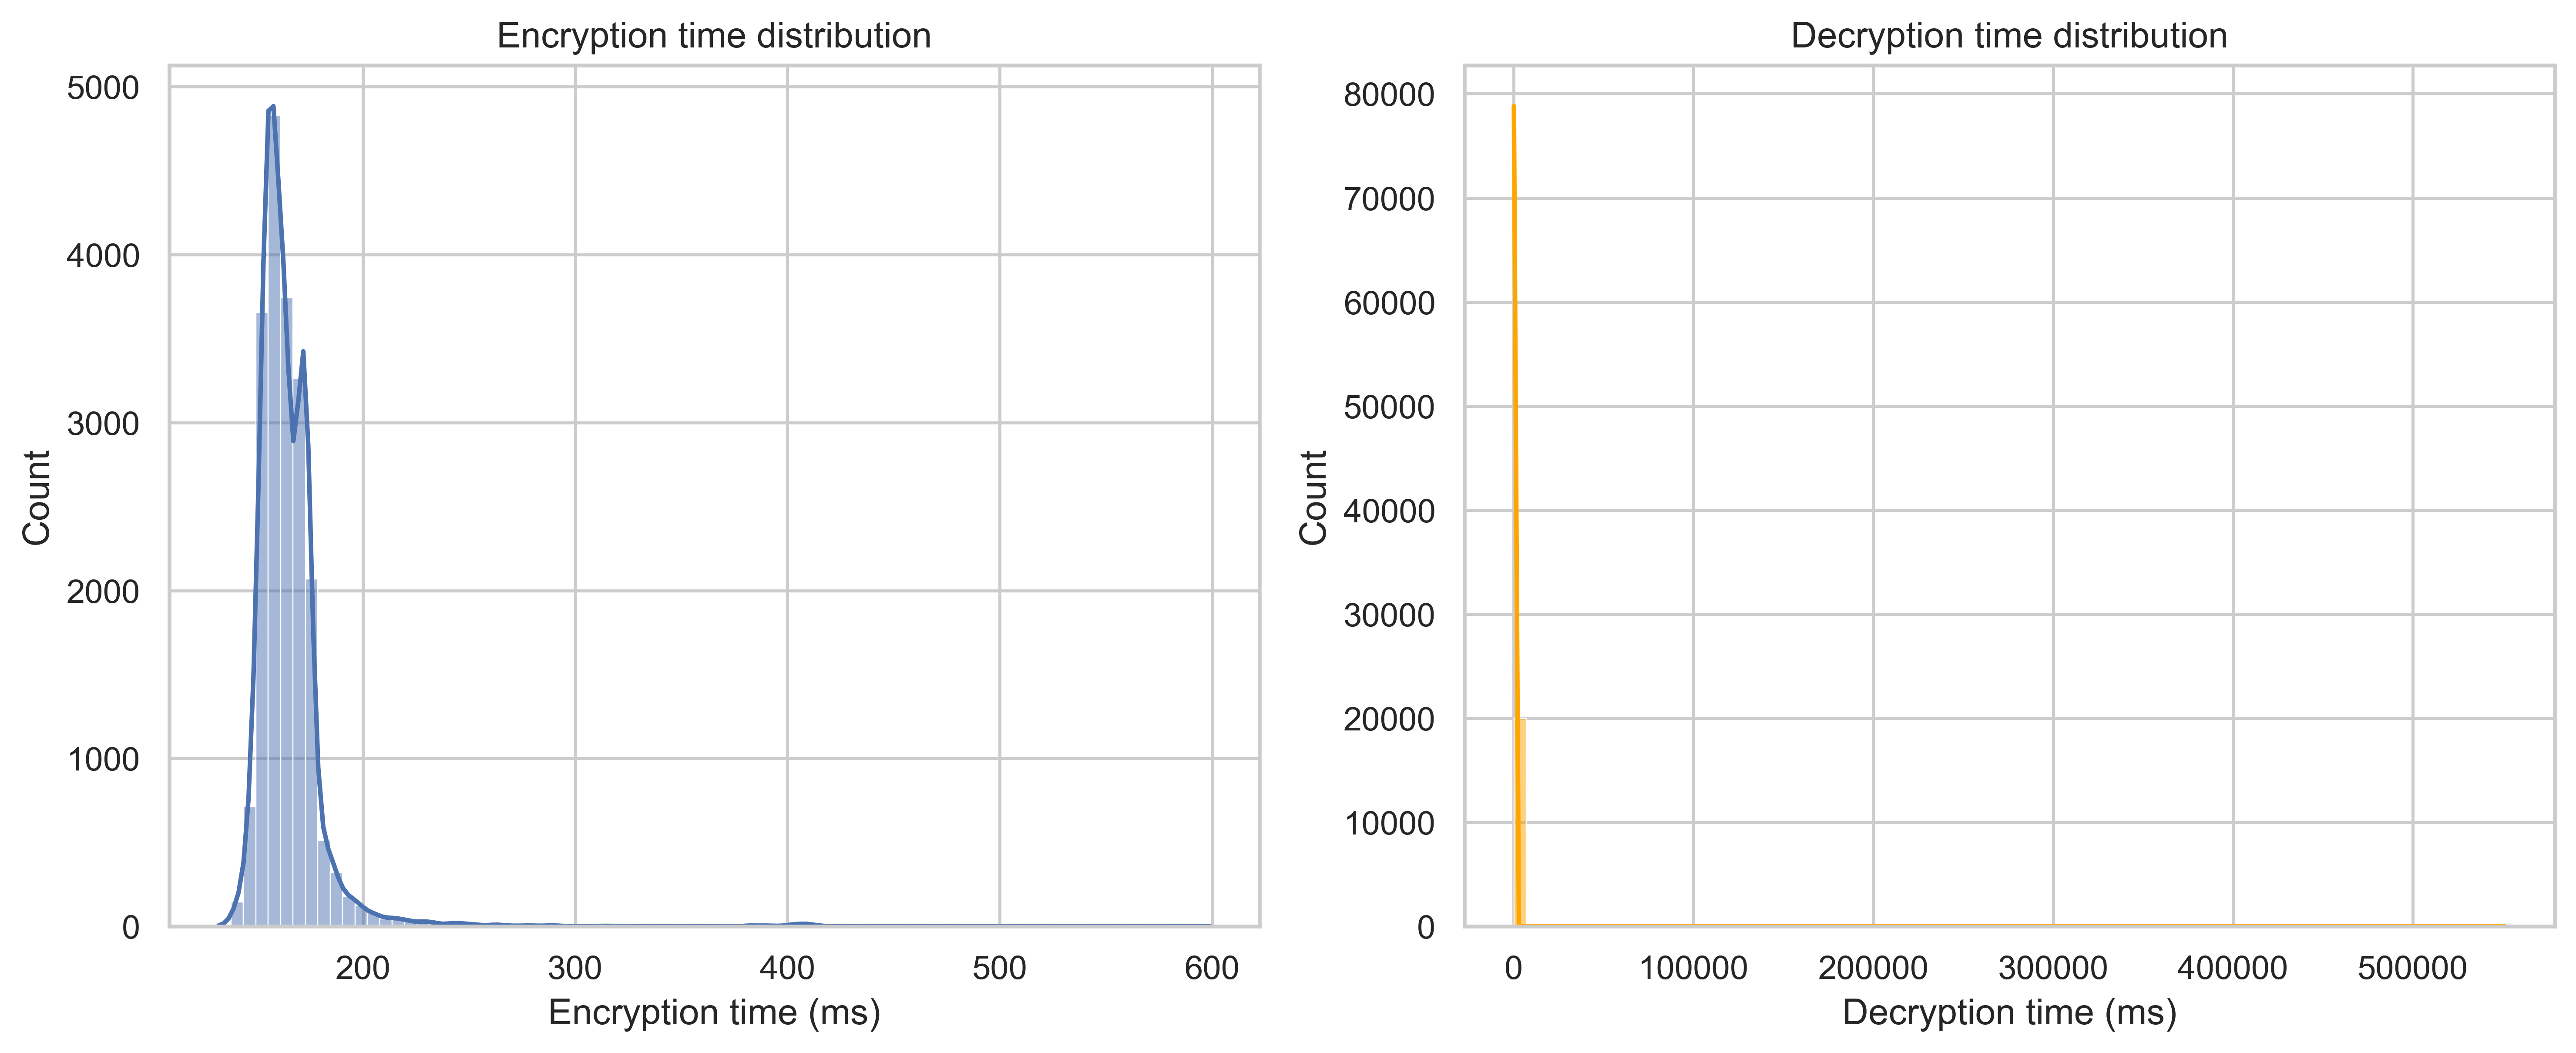

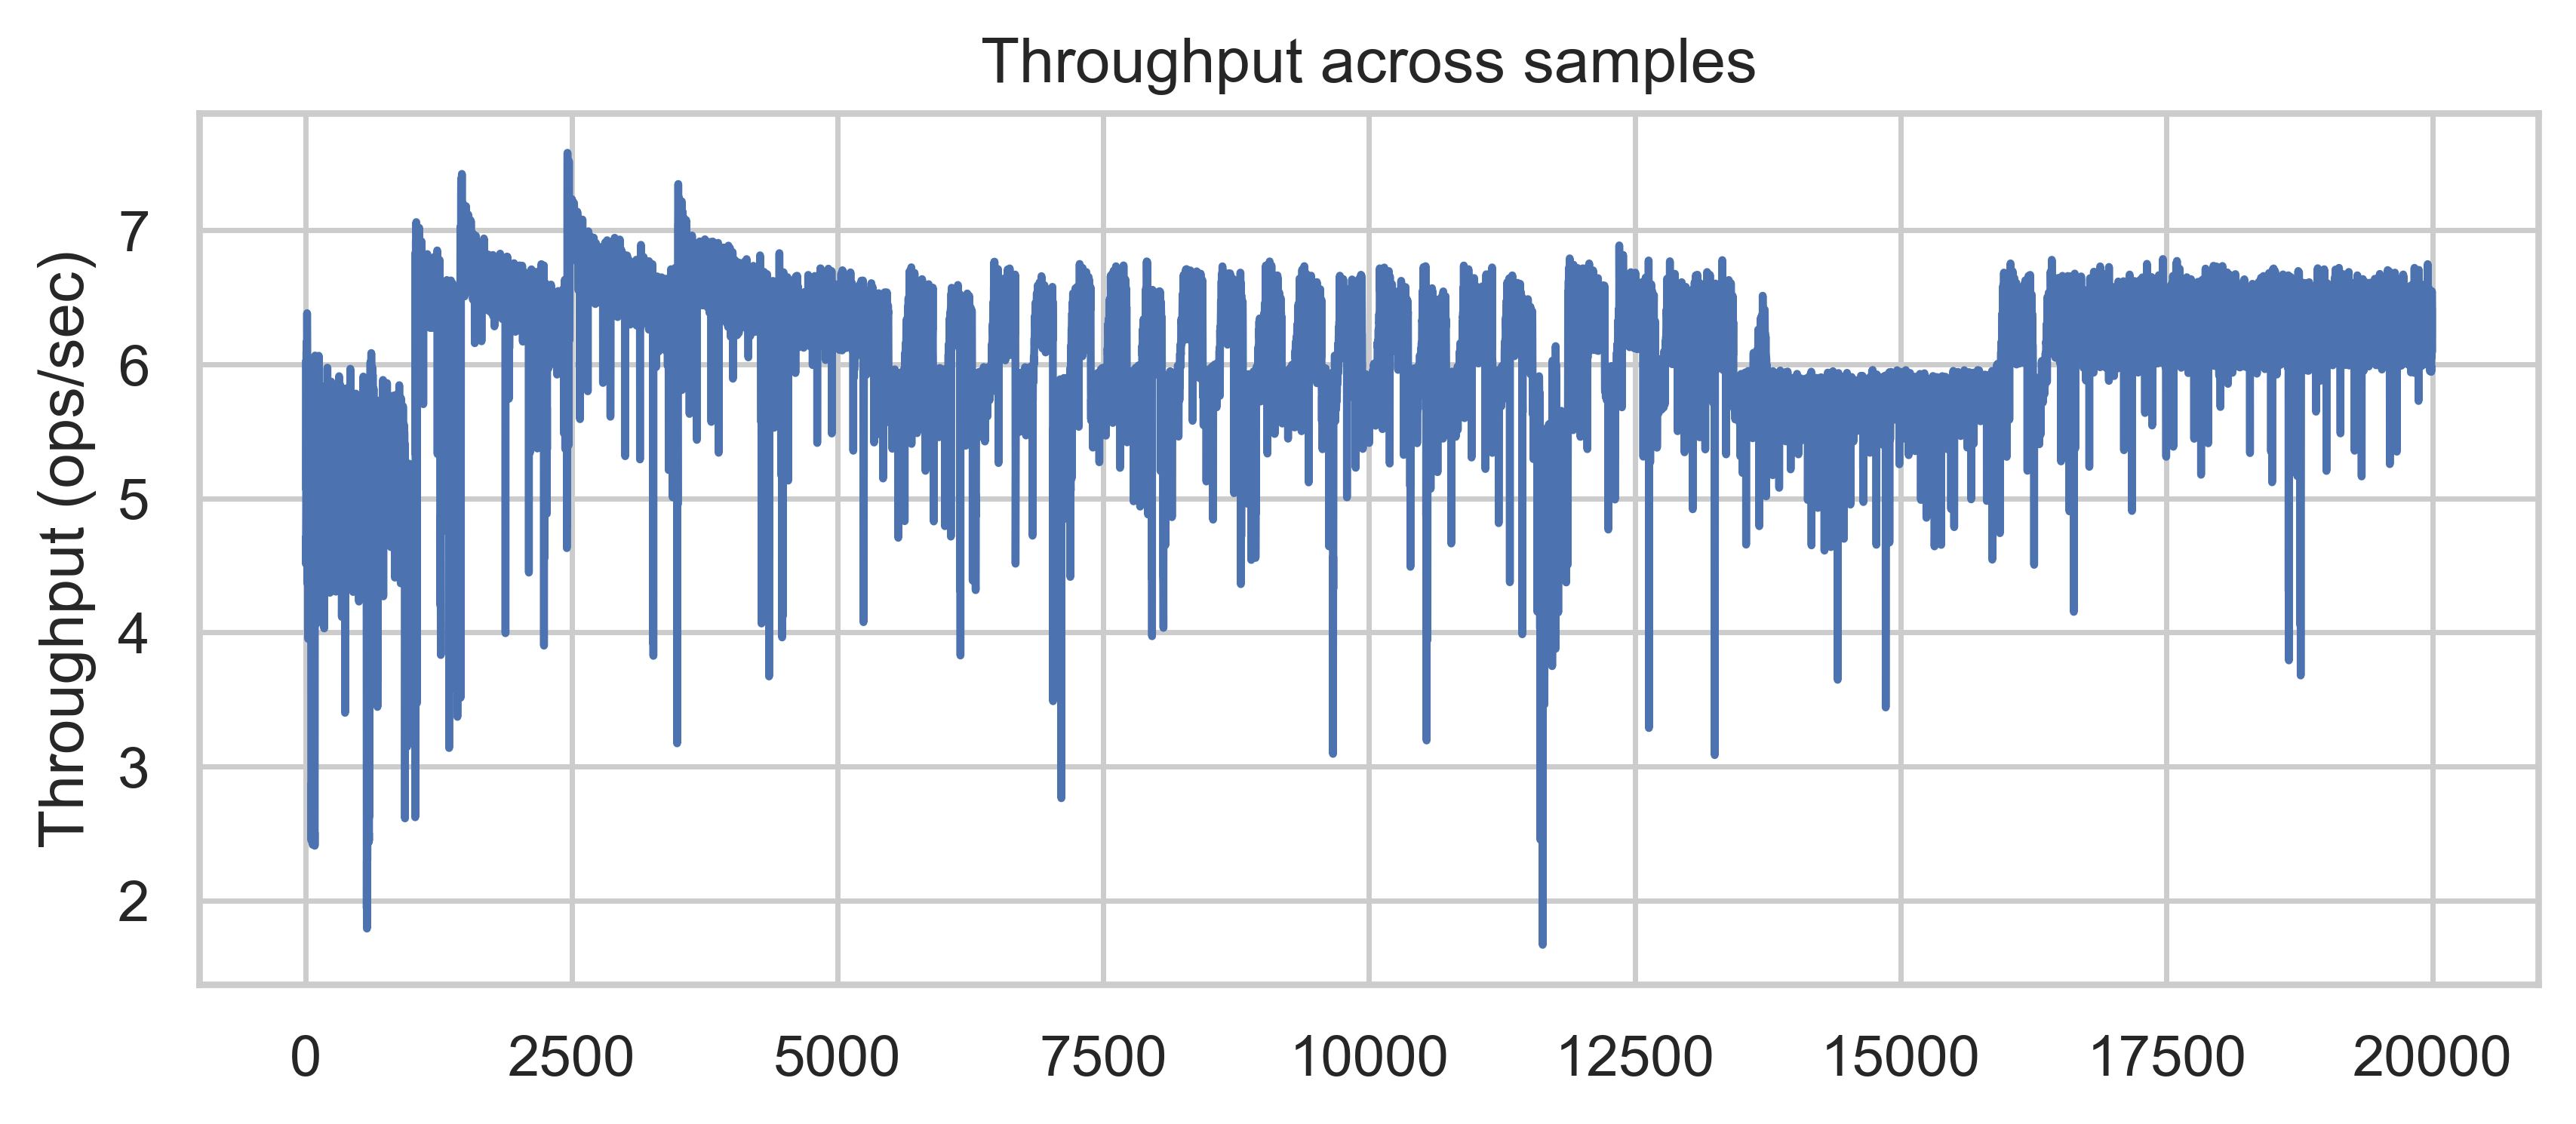

Saved performance tables.


In [11]:
# Cell 6: Performance visuals and tables
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['enc_time_s']*1000, bins=80, kde=True)
plt.xlabel("Encryption time (ms)")
plt.title("Encryption time distribution")

plt.subplot(1,2,2)
sns.histplot(df['dec_time_s']*1000, bins=80, kde=True, color='orange')
plt.xlabel("Decryption time (ms)")
plt.title("Decryption time distribution")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "enc_dec_time_distribution.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Throughput table & graph
df['throughput_ops_sec'] = (1.0 / df['enc_time_s']).replace([np.inf, -np.inf], np.nan)
throughput_stats = df['throughput_ops_sec'].describe()
throughput_stats.to_csv(os.path.join(SAVE_DIR, "throughput_stats.csv"))
plt.figure(figsize=(8,3))
sns.lineplot(df['throughput_ops_sec'].reset_index(drop=True))
plt.ylabel("Throughput (ops/sec)")
plt.title("Throughput across samples")
plt.savefig(os.path.join(SAVE_DIR, "throughput_line.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Save table for encryption/decryption times
enc_dec_table = df[['enc_time_s','dec_time_s']].describe().T
enc_dec_table.to_csv(os.path.join(SAVE_DIR, "enc_dec_summary.csv"))
print("Saved performance tables.")


Entropy mean: 6.536897612498443 std: 0.4356572978556524


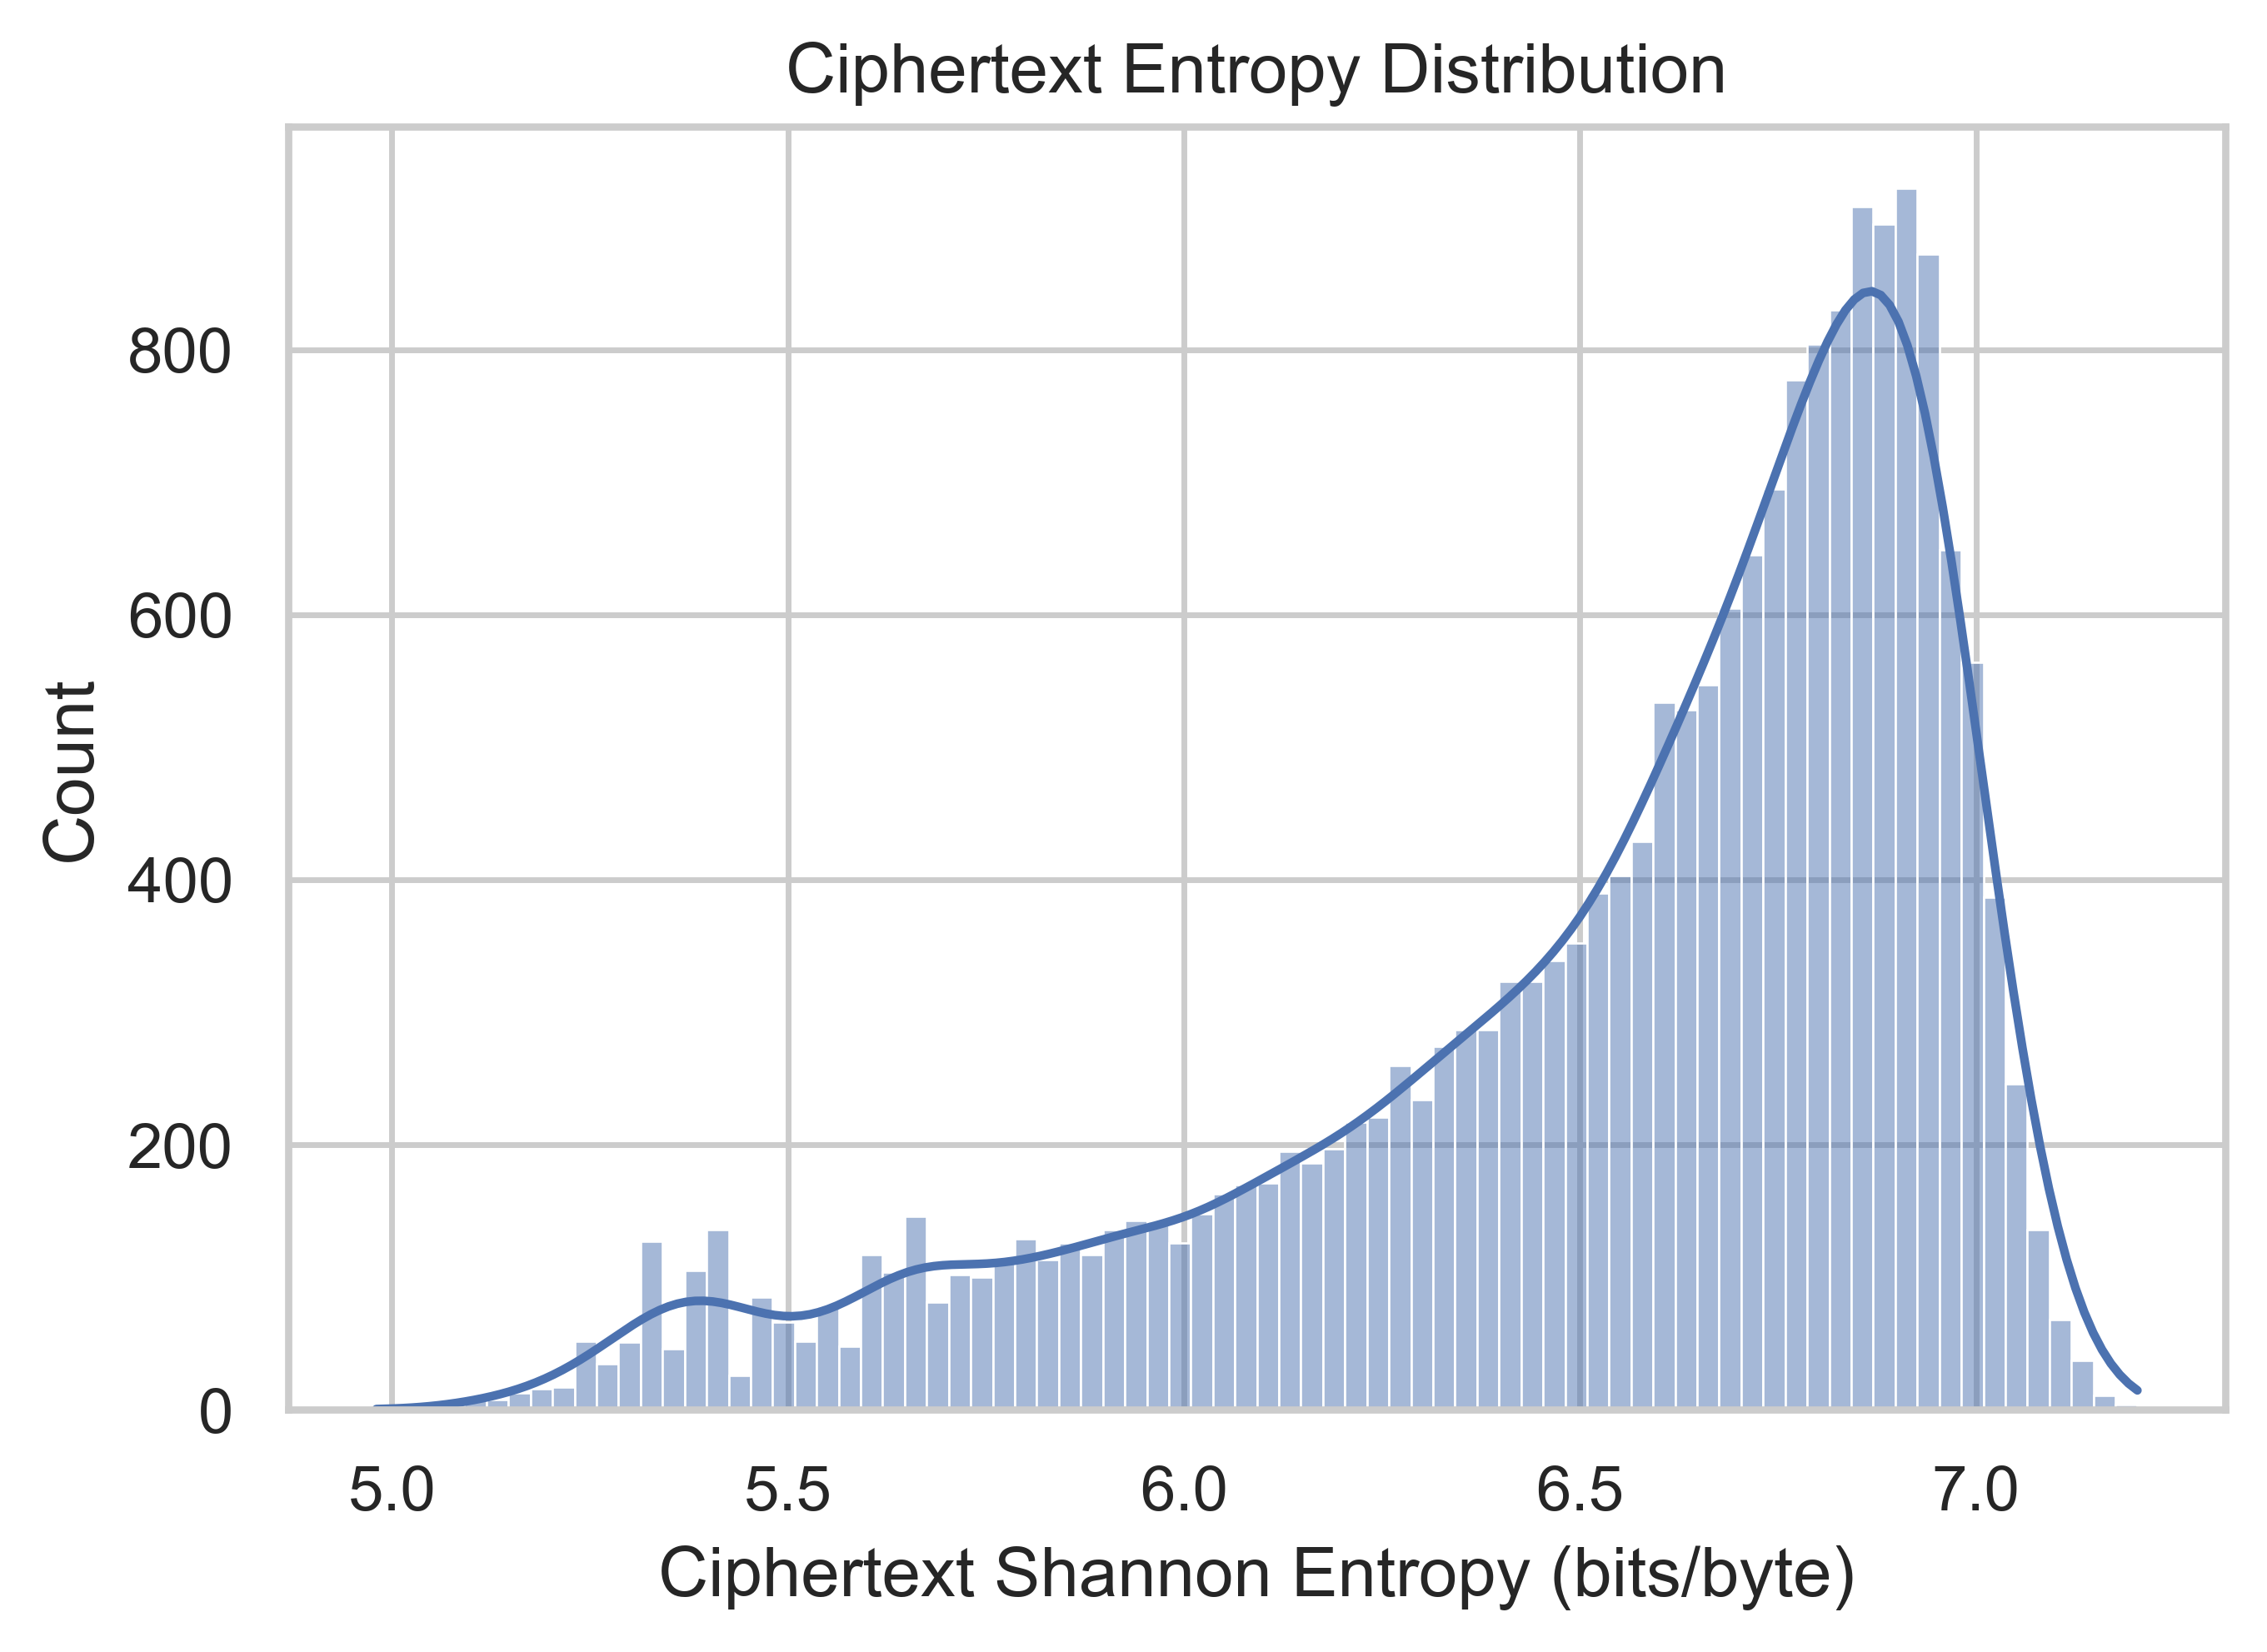

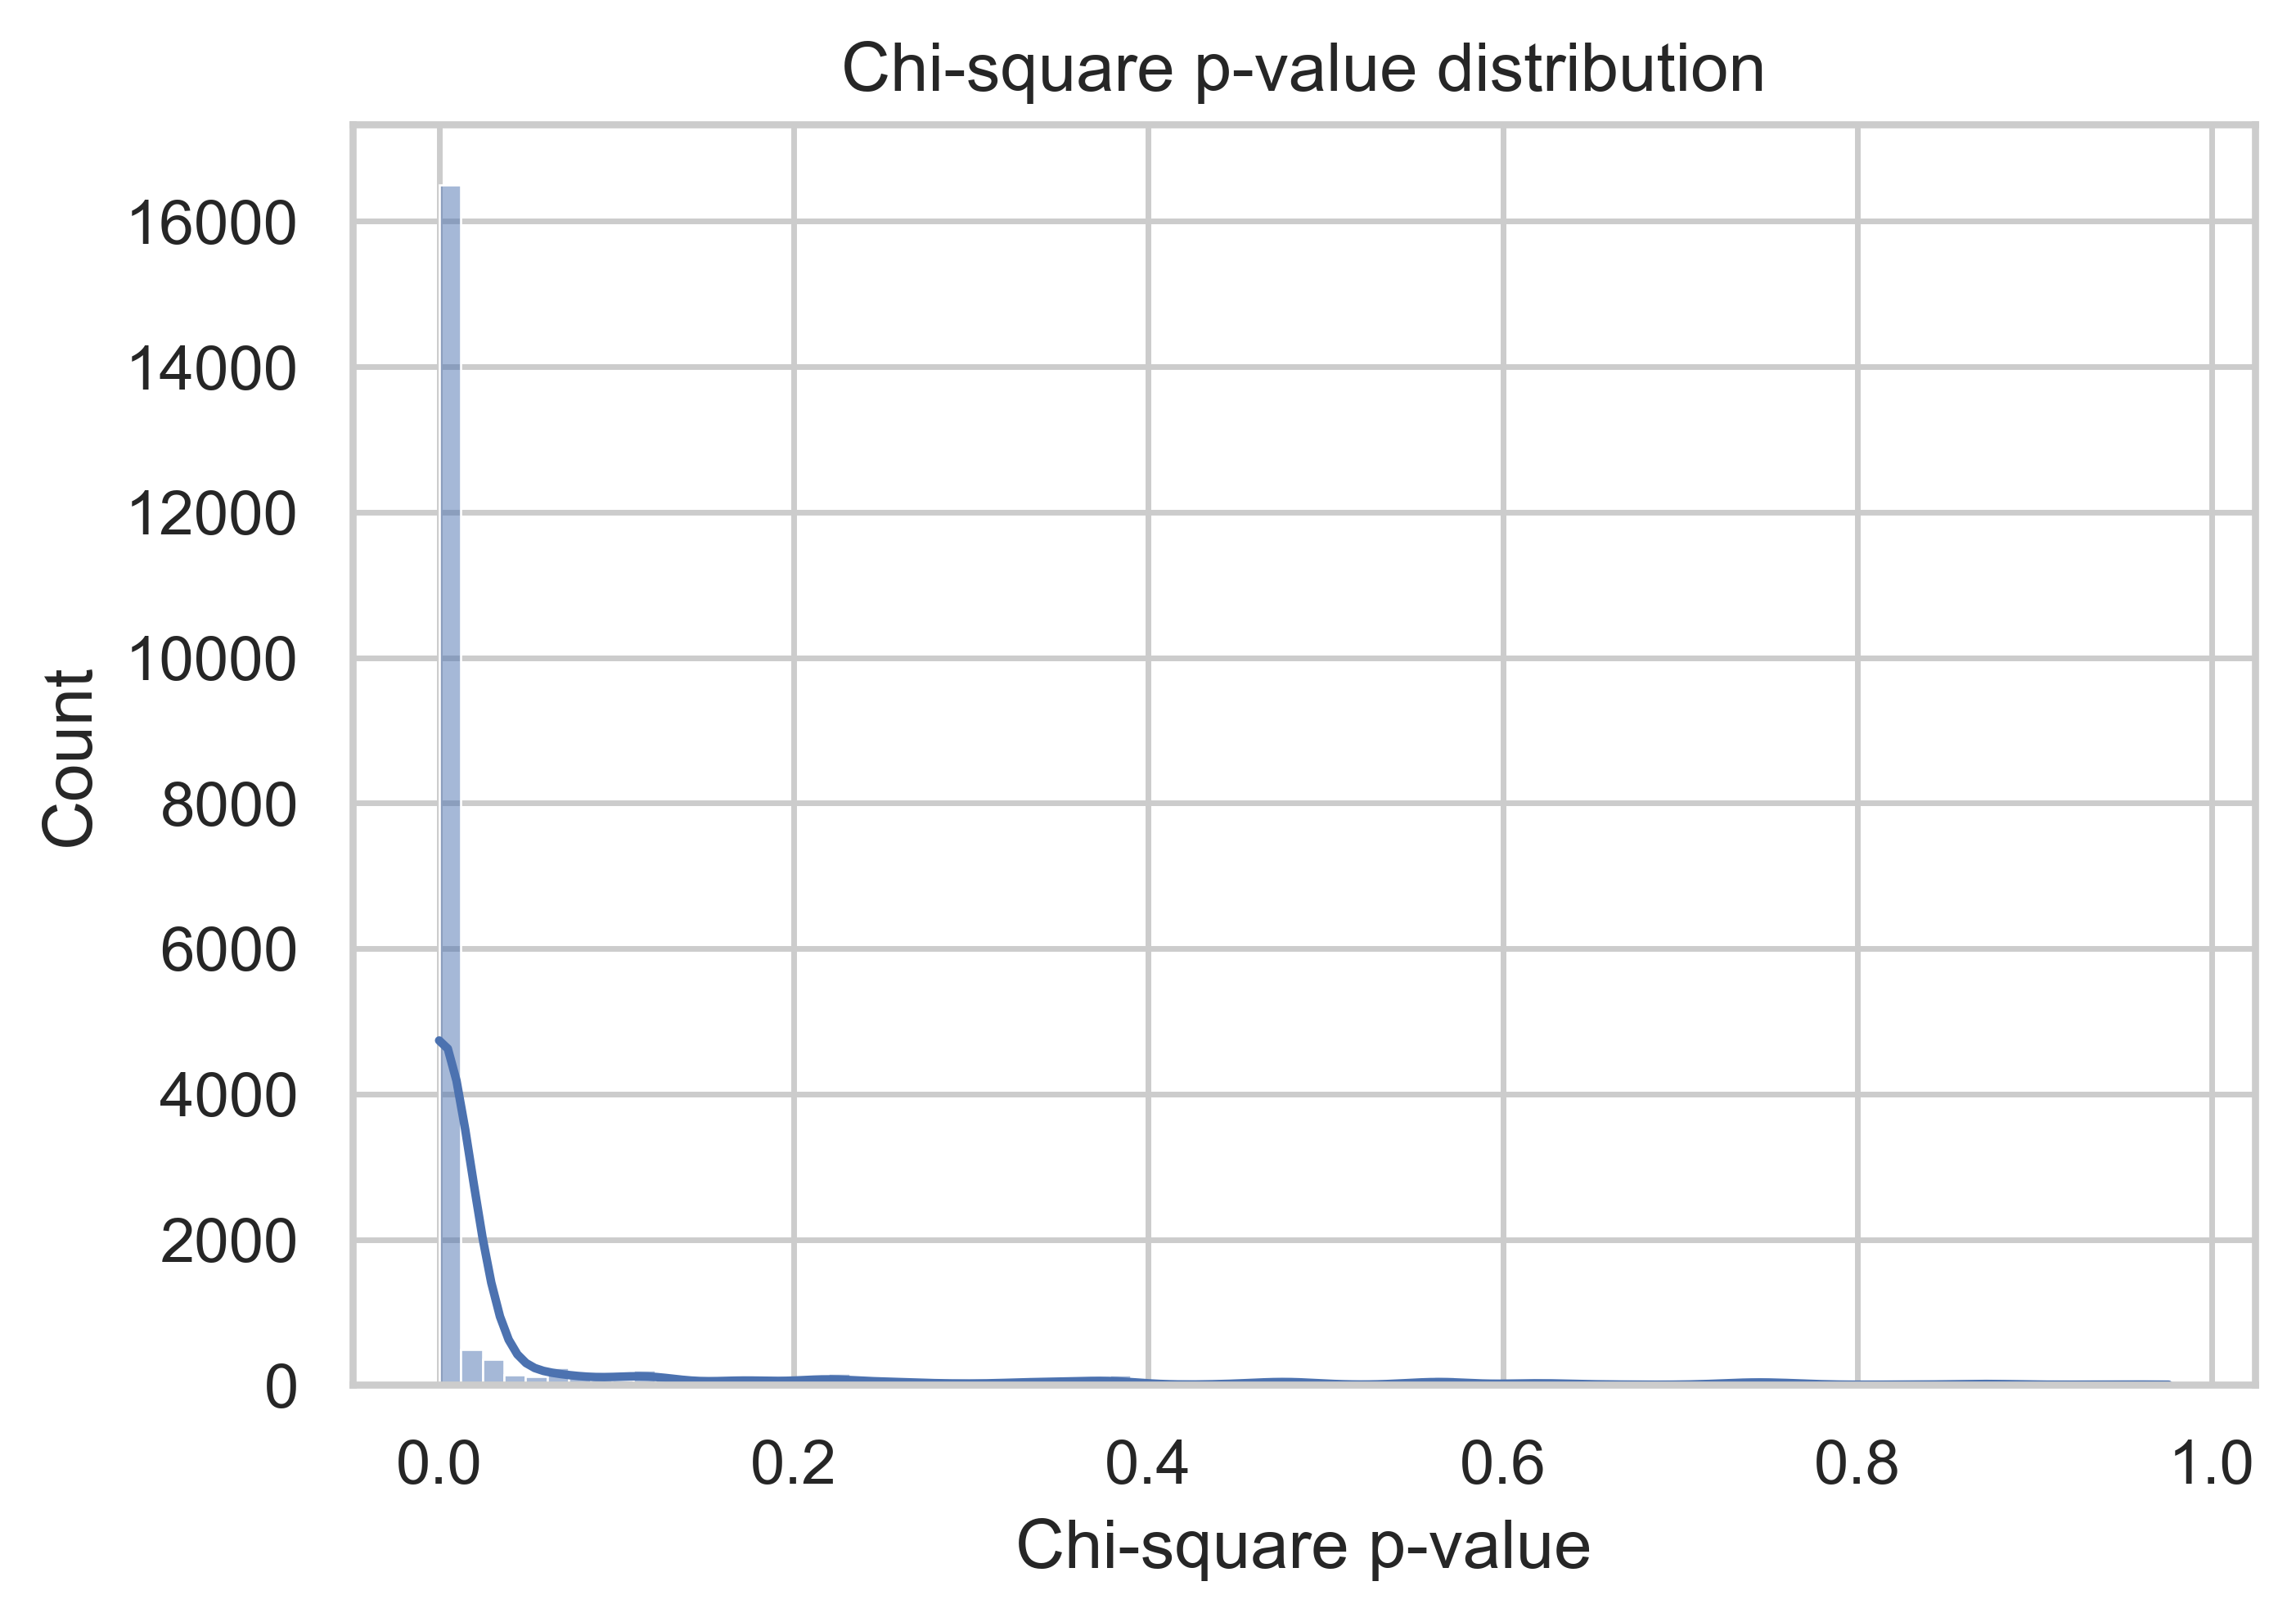

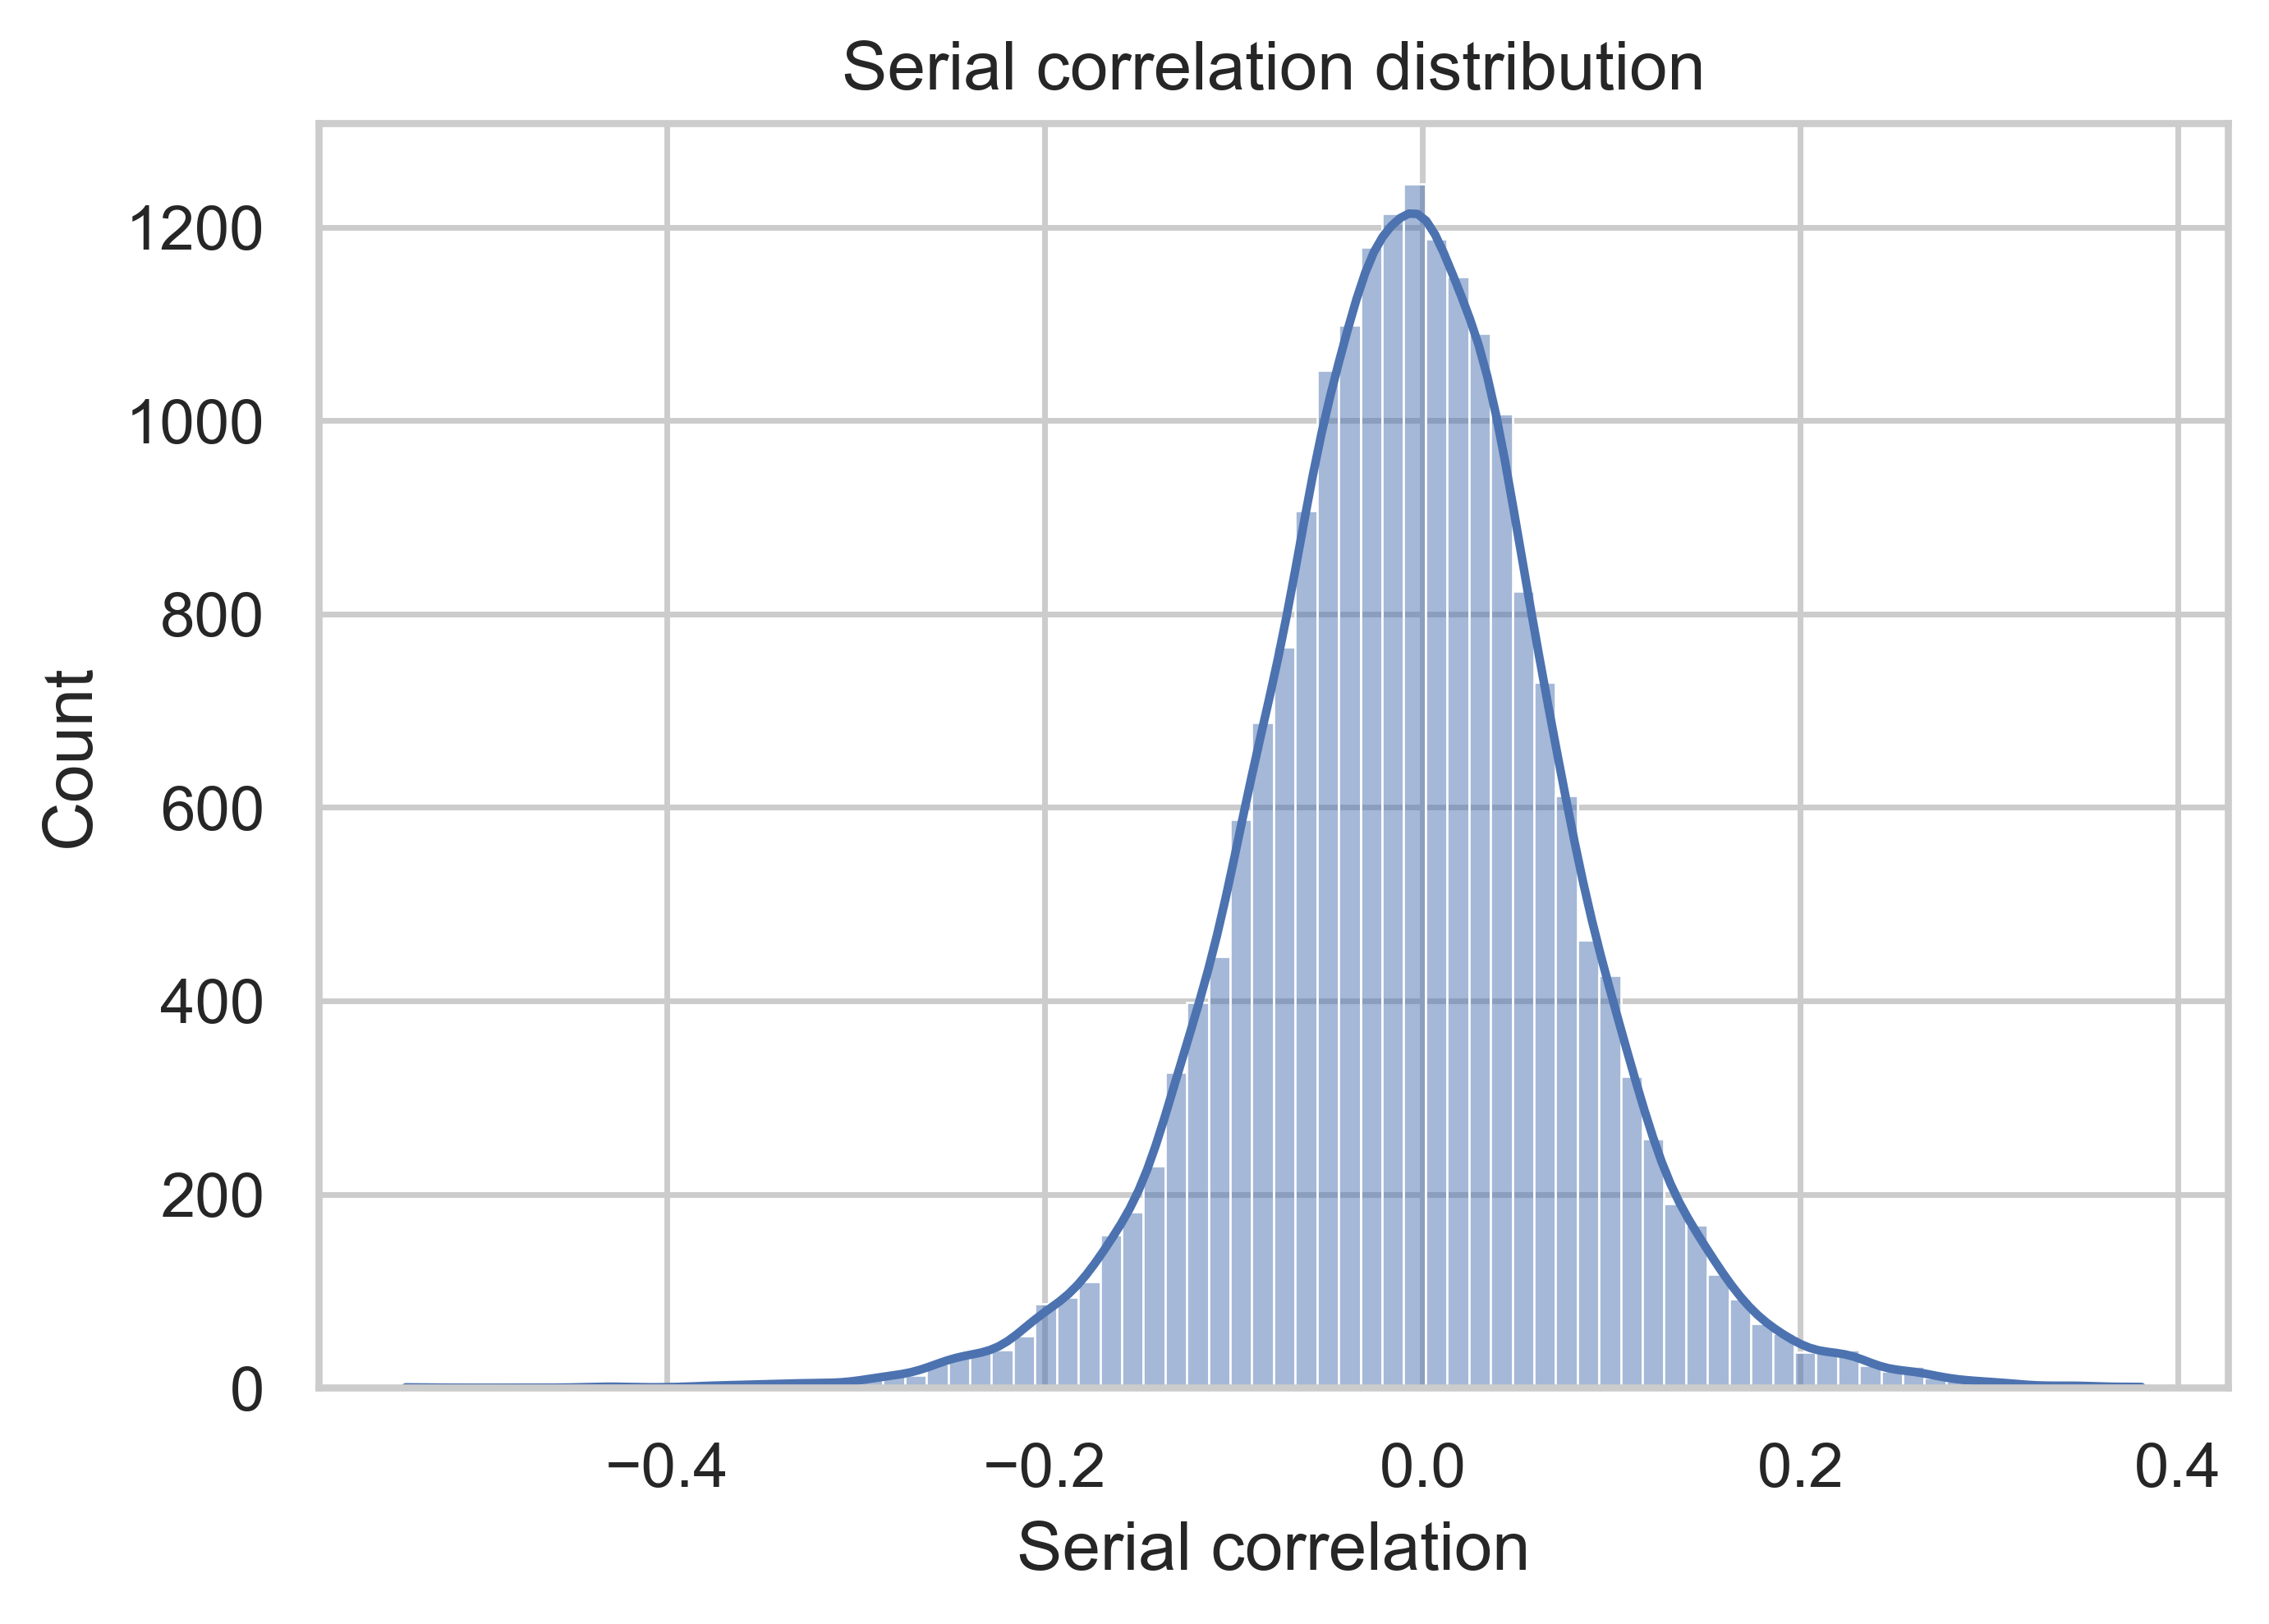

In [12]:
# Cell 7: Entropy & randomness tests
print("Entropy mean:", df['cipher_entropy'].mean(), "std:", df['cipher_entropy'].std())

plt.figure(figsize=(6,4))
sns.histplot(df['cipher_entropy'], bins=80, kde=True)
plt.xlabel("Ciphertext Shannon Entropy (bits/byte)")
plt.title("Ciphertext Entropy Distribution")
plt.savefig(os.path.join(SAVE_DIR, "entropy_hist.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Chi-square p-values
plt.figure(figsize=(6,4))
sns.histplot(df['chi_p'].dropna(), bins=80, kde=True)
plt.xlabel("Chi-square p-value")
plt.title("Chi-square p-value distribution")
plt.savefig(os.path.join(SAVE_DIR, "chi_pvals.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Serial correlation
plt.figure(figsize=(6,4))
sns.histplot(df['serial_corr'].dropna(), bins=80, kde=True)
plt.xlabel("Serial correlation")
plt.title("Serial correlation distribution")
plt.savefig(os.path.join(SAVE_DIR, "serial_corr.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Save tables
df[['cipher_entropy','chi2','chi_p','serial_corr']].describe().to_csv(os.path.join(SAVE_DIR, "entropy_chi_serial_summary.csv"))


Avalanche mean: 50.009056784993795 std: 1.4313896646974904
Key-sensitivity mean: 49.9612669526772 std: 1.361381619185754


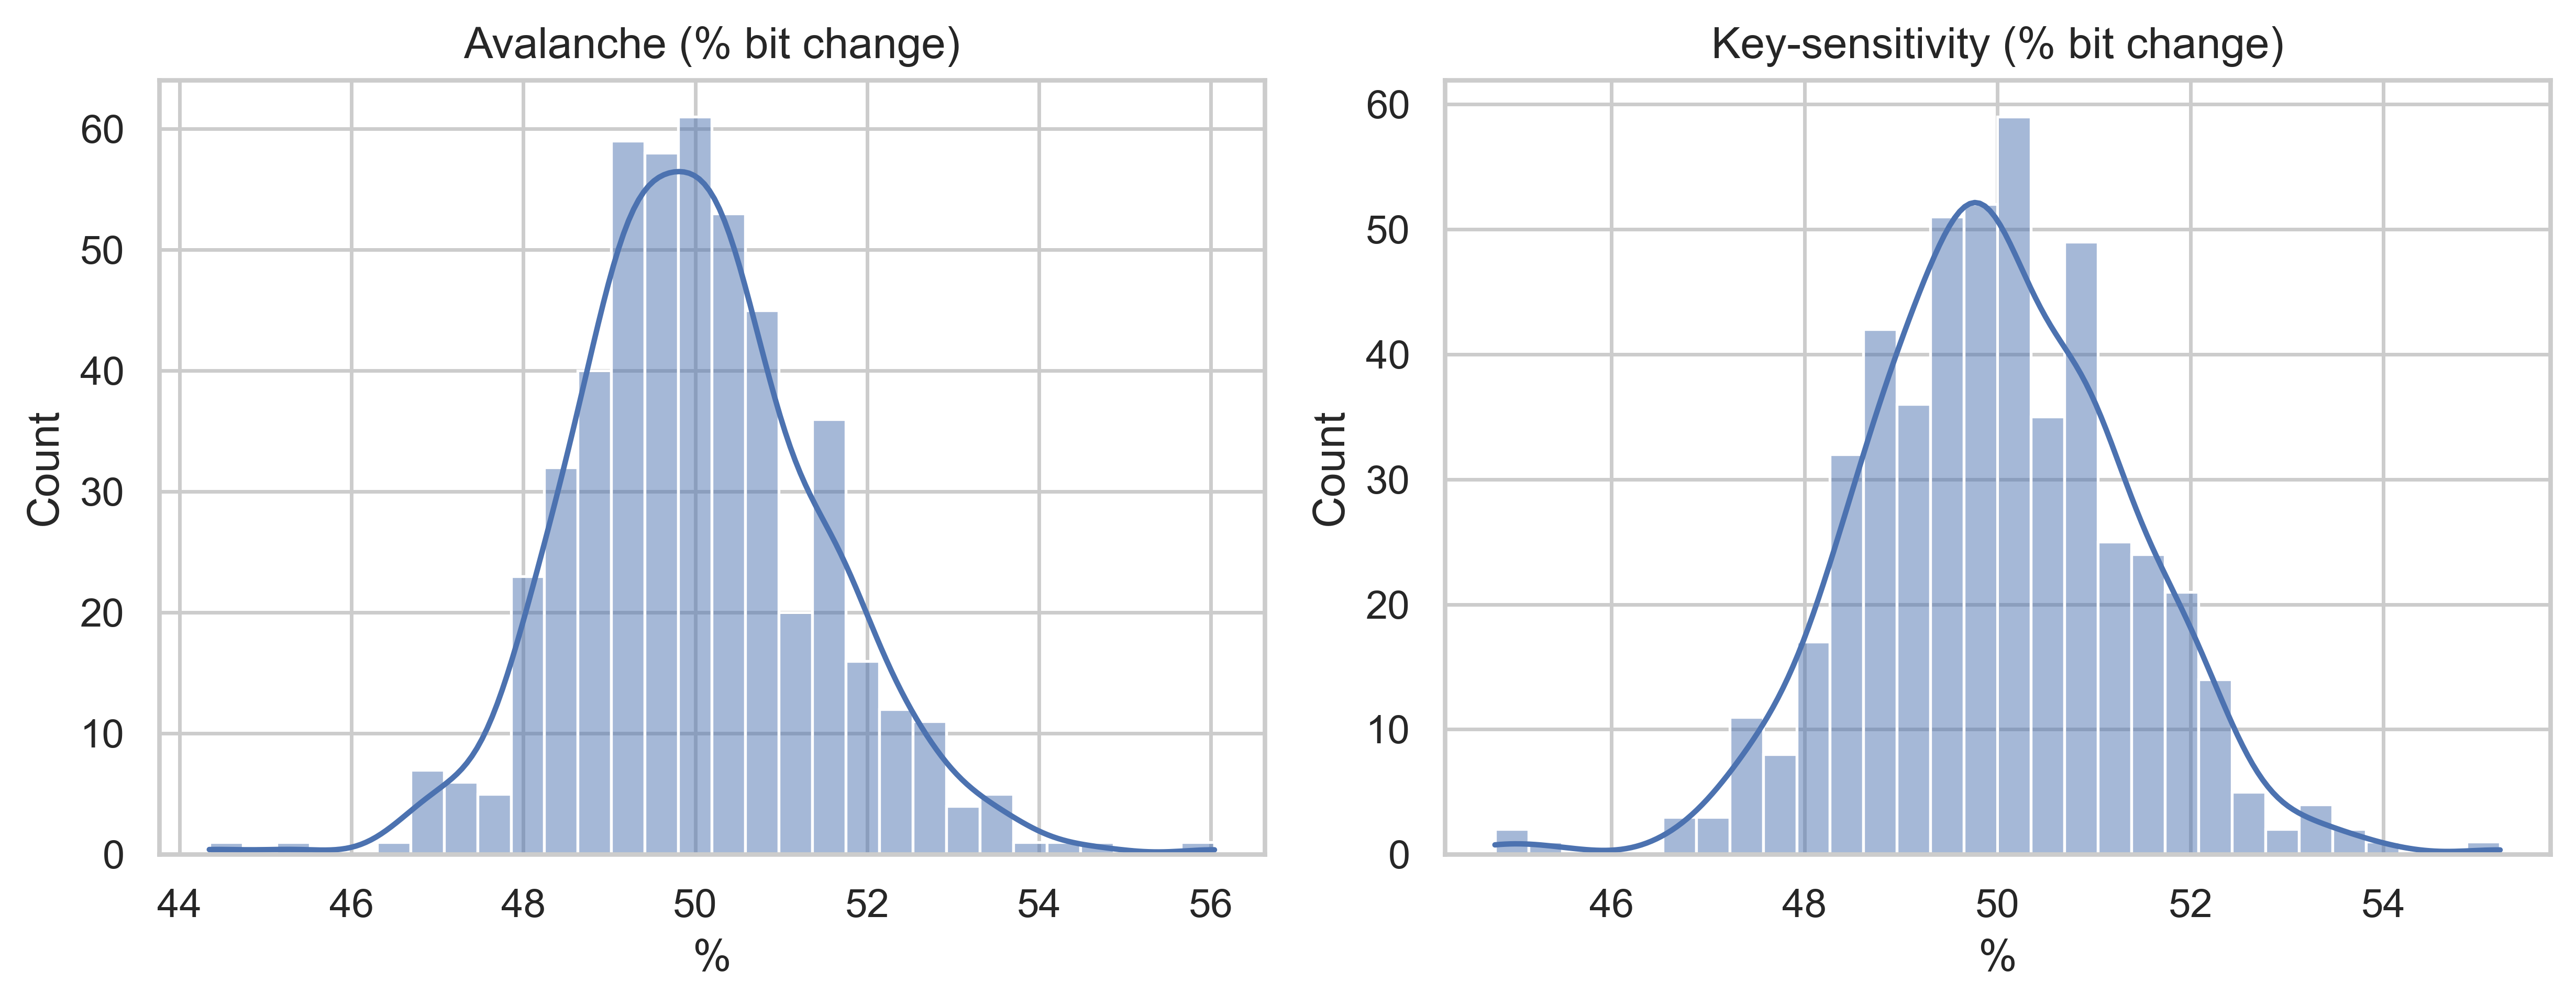

In [13]:
# Cell 8: Avalanche & key-sensitivity sampling
def avalanche_one(pw, pt):
    env1 = encrypt_numeric(pw, pt)
    if len(pt)==0: return None
    pos = RNG.randrange(len(pt))
    pt2 = pt[:pos] + chr(ord(pt[pos]) ^ 1) + pt[pos+1:]
    env2 = encrypt_numeric(pw, pt2)
    b1 = bytes_from_cipher_digits(env1.get("cipher",""))
    b2 = bytes_from_cipher_digits(env2.get("cipher",""))
    L = min(len(b1), len(b2))
    if L==0: return None
    bits1 = bits_from_bytes(b1[:L]); bits2 = bits_from_bytes(b2[:L])
    return hamming_distance_bits(bits1,bits2)/(L*8)*100

def key_sens_one(pw, pt):
    env1 = encrypt_numeric(pw, pt)
    if len(pw)==0: return None
    pos = RNG.randrange(len(pw))
    pw2 = pw[:pos] + chr(ord(pw[pos]) ^ 1) + pw[pos+1:]
    env2 = encrypt_numeric(pw2, pt)
    b1 = bytes_from_cipher_digits(env1.get("cipher",""))
    b2 = bytes_from_cipher_digits(env2.get("cipher",""))
    L = min(len(b1), len(b2))
    if L==0: return None
    return hamming_distance_bits(bits_from_bytes(b1[:L]), bits_from_bytes(b2[:L]))/(L*8)*100

avals=[]; kvals=[]
for _ in range(AVALANCHE_SAMPLES):
    pw, pt = testcases[RNG.randrange(len(testcases))]
    a = avalanche_one(pw, pt)
    k = key_sens_one(pw, pt)
    if a is not None: avals.append(a)
    if k is not None: kvals.append(k)

print("Avalanche mean:", mean(avals), "std:", stdev(avals))
print("Key-sensitivity mean:", mean(kvals), "std:", stdev(kvals))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(avals, bins=30, kde=True); plt.title("Avalanche (% bit change)"); plt.xlabel("%")
plt.subplot(1,2,2)
sns.histplot(kvals, bins=30, kde=True); plt.title("Key-sensitivity (% bit change)"); plt.xlabel("%")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "avalanche_key_sensitivity.png"), dpi=EXPORT_PNG_DPI)
plt.show()

# Save tables
pd.DataFrame({"avalanche":avals}).describe().to_csv(os.path.join(SAVE_DIR, "avalanche_stats.csv"))
pd.DataFrame({"key_sensitivity":kvals}).describe().to_csv(os.path.join(SAVE_DIR, "key_sensitivity_stats.csv"))


Mean abs diffusion correlation (should be near 0): 0.027880761547054905


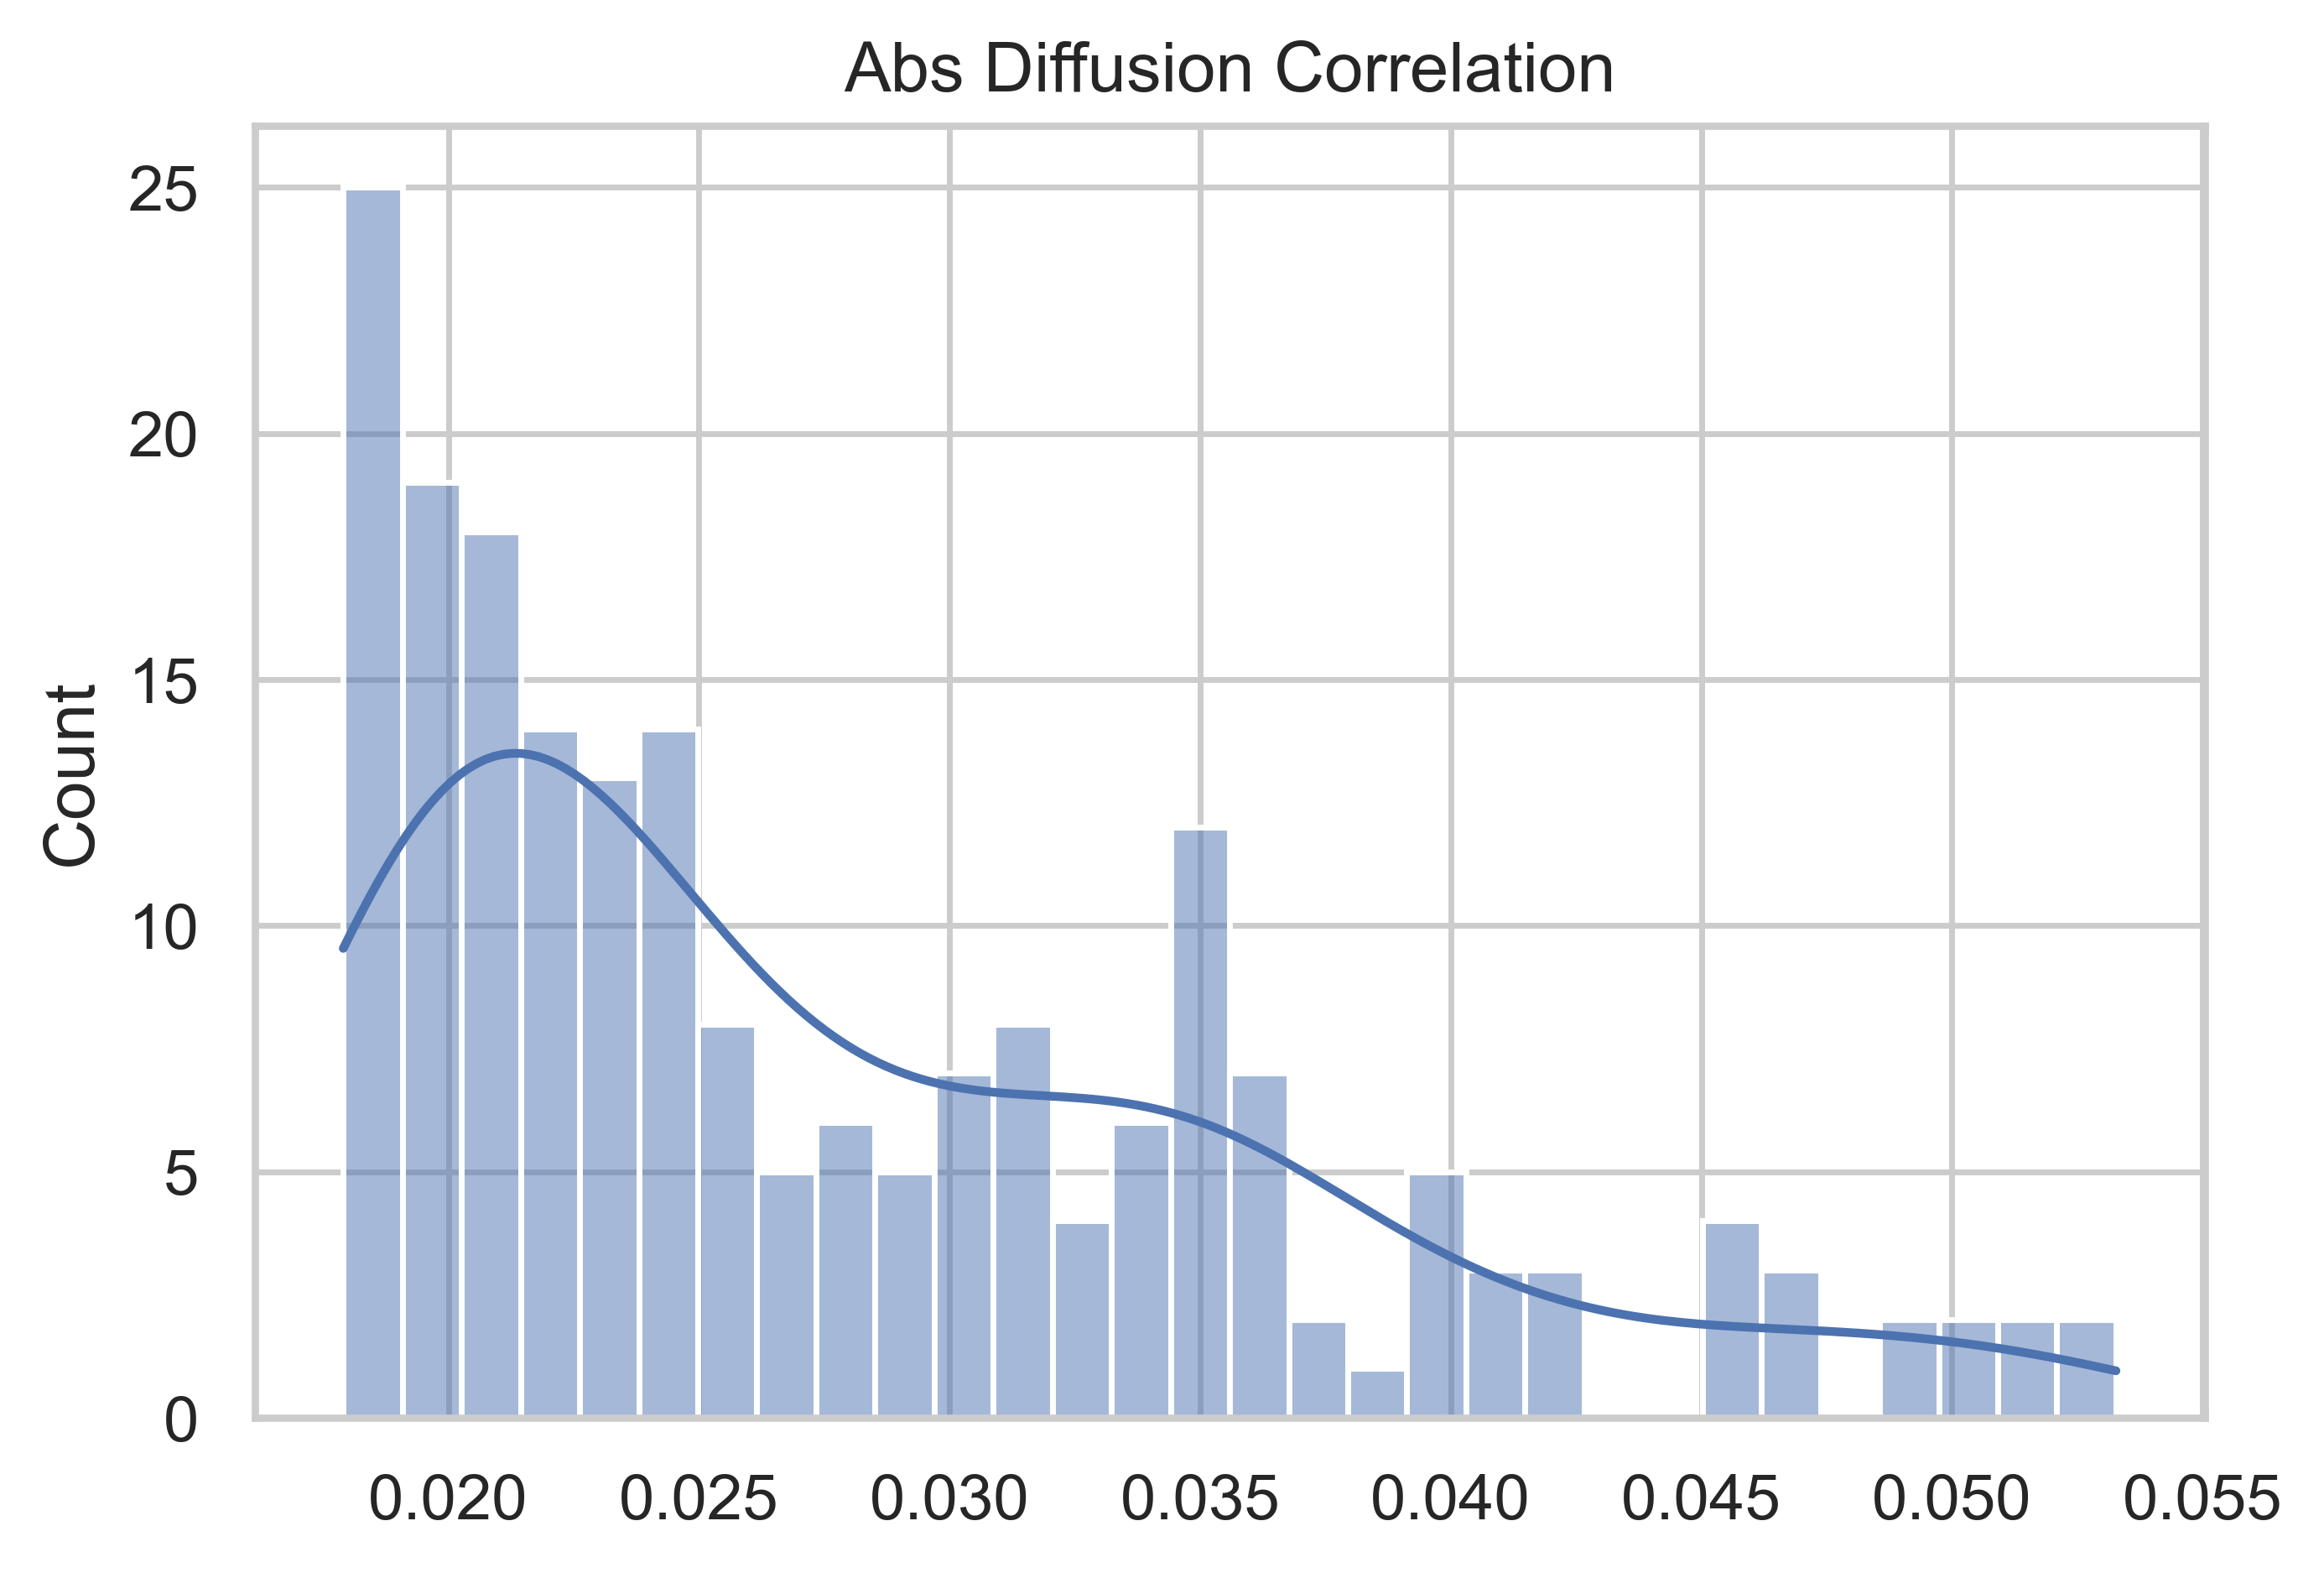

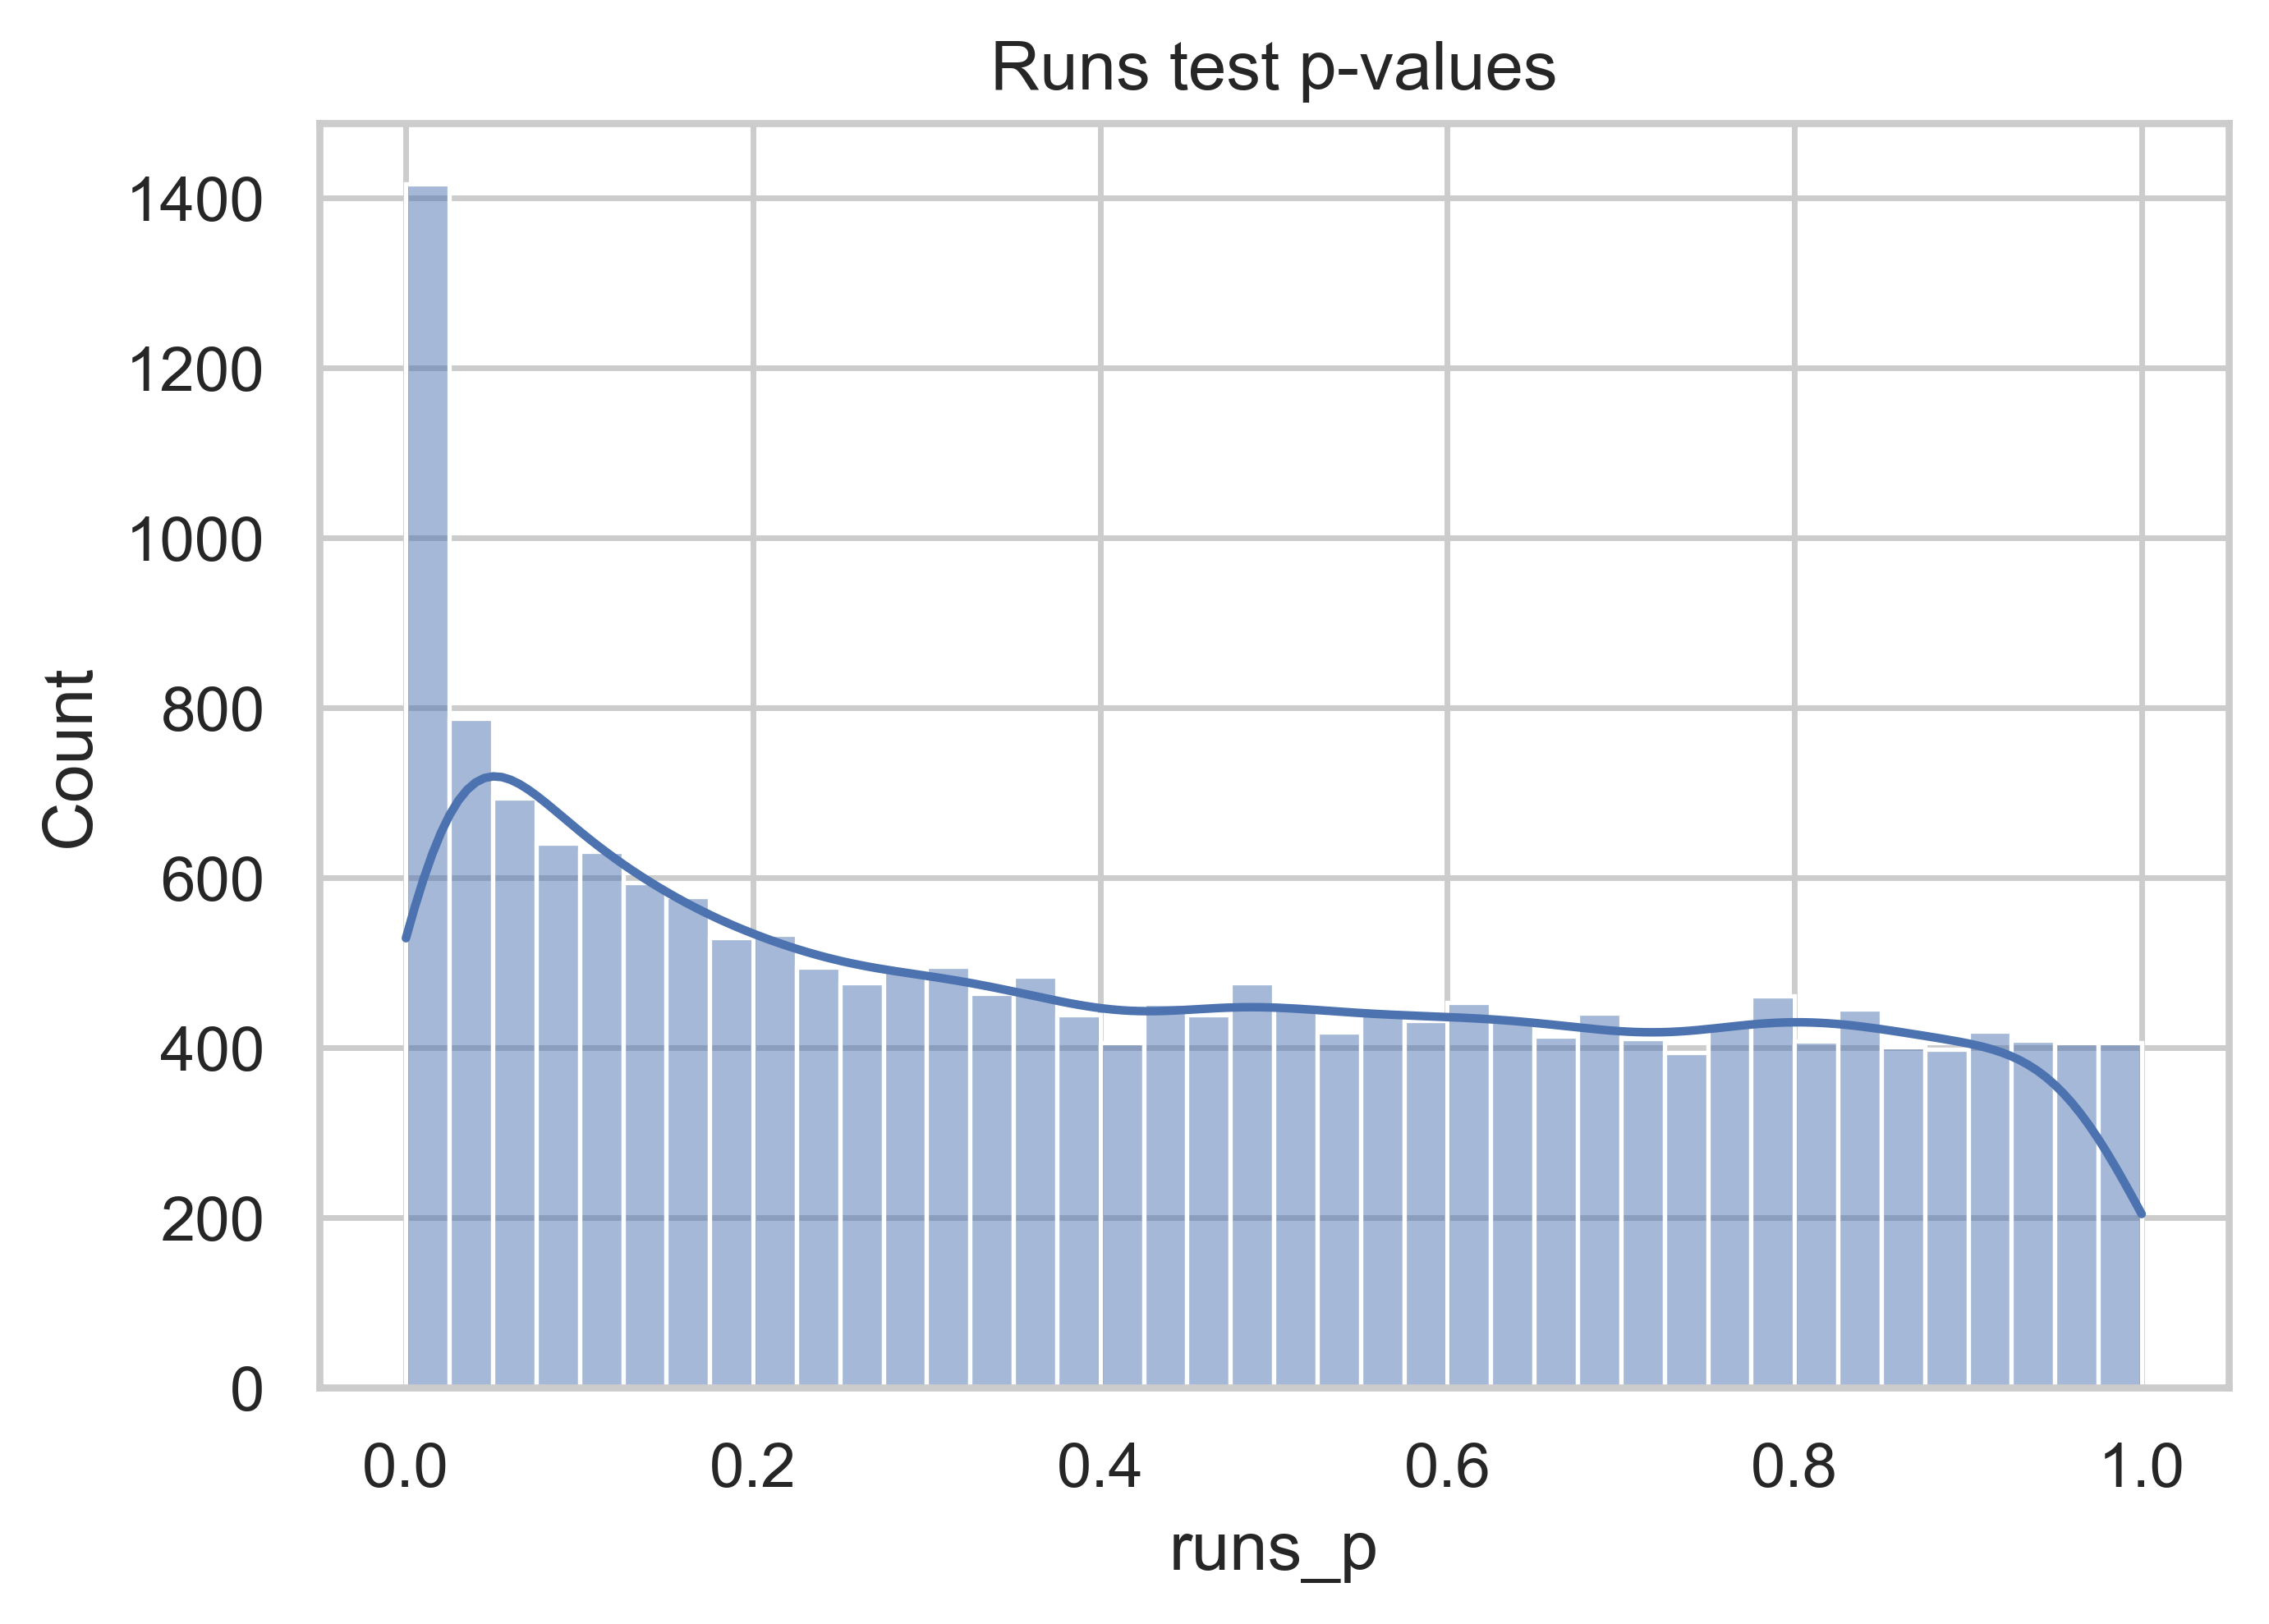

In [14]:
# Cell 9: Diffusion (correlation) approximate sampling & runs test
corrs=[]
for _ in range(200):
    pw, pt = testcases[RNG.randrange(len(testcases))]
    if len(pt)<1: continue
    pos = RNG.randrange(len(pt))
    pt2 = pt[:pos] + chr(ord(pt[pos]) ^ 1) + pt[pos+1:]
    env1 = encrypt_numeric(pw, pt); env2 = encrypt_numeric(pw, pt2)
    b1 = bytes_from_cipher_digits(env1.get("cipher","")); b2 = bytes_from_cipher_digits(env2.get("cipher",""))
    L = min(len(b1), len(b2))
    if L==0: continue
    bits1 = np.array(list(bits_from_bytes(b1[:L])), dtype=int)
    bits2 = np.array(list(bits_from_bytes(b2[:L])), dtype=int)
    diff = bits1 ^ bits2
    inp = np.zeros_like(diff); inp[0]=1
    if diff.var()==0: continue
    corr = np.corrcoef(inp, diff)[0,1]
    corrs.append(corr)

print("Mean abs diffusion correlation (should be near 0):", np.mean(np.abs(corrs)))
plt.figure(figsize=(6,4)); sns.histplot(np.abs(corrs), bins=30, kde=True); plt.title("Abs Diffusion Correlation")
plt.savefig(os.path.join(SAVE_DIR, "diffusion_correlation.png"), dpi=EXPORT_PNG_DPI); plt.show()

# Runs p-values distribution
plt.figure(figsize=(6,4)); sns.histplot(df['runs_p'].dropna(), bins=40, kde=True); plt.title("Runs test p-values")
plt.savefig(os.path.join(SAVE_DIR, "runs_pvals.png"), dpi=EXPORT_PNG_DPI); plt.show()
df['runs_p'].describe().to_csv(os.path.join(SAVE_DIR, "runs_pvals_stats.csv"))


In [15]:
# Cell 10: Resource & energy
cpu_before_mean = df['cpu_before'].mean(); cpu_after_mean = df['cpu_after'].mean()
mem_before_mean = df['mem_before_mb'].mean(); mem_after_mean = df['mem_after_mb'].mean()
avg_enc_ms = df['enc_time_s'].mean()*1000; avg_dec_ms = df['dec_time_s'].mean()*1000

print(f"Avg CPU before/after: {cpu_before_mean:.2f}% / {cpu_after_mean:.2f}%")
print(f"Avg memory before/after (MB): {mem_before_mean:.2f} / {mem_after_mean:.2f}")
print(f"Avg encryption time: {avg_enc_ms:.2f} ms; Avg decryption time: {avg_dec_ms:.2f} ms")

# Proxy energy (assume CPU 20W)
cpu_power_w = 20.0
energy_per_enc_j = df['enc_time_s'].mean() * cpu_power_w
energy_per_dec_j = df['dec_time_s'].mean() * cpu_power_w
print(f"Proxy energy per encryption: {energy_per_enc_j:.4f} J; per decryption: {energy_per_dec_j:.4f} J")

res_table = pd.DataFrame({
    "metric":["avg_enc_ms","avg_dec_ms","energy_enc_J","energy_dec_J","cpu_before","cpu_after","mem_before_mb","mem_after_mb"],
    "value":[avg_enc_ms, avg_dec_ms, energy_per_enc_j, energy_per_dec_j, cpu_before_mean, cpu_after_mean, mem_before_mean, mem_after_mean]
})
res_table.to_csv(os.path.join(SAVE_DIR, "resource_summary.csv"), index=False)
print("Saved resource_summary.csv")


Avg CPU before/after: 7.80% / 15.92%
Avg memory before/after (MB): 220.50 / 220.50
Avg encryption time: 165.11 ms; Avg decryption time: 224.89 ms
Proxy energy per encryption: 3.3022 J; per decryption: 4.4979 J
Saved resource_summary.csv


In [16]:
# Cell 11: Collision check for all ciphertexts in dataset (exact)
cipher_counts = df['cipher_digits'].value_counts() if 'cipher_digits' in df.columns else df['cipher_digits'].value_counts()
# If storing entire cipher string is heavy, you may hash it first
if 'cipher_digits' in df.columns:
    coll_total = (cipher_counts > 1).sum()
    print("Total cipher collisions in dataset:", coll_total)
    cipher_counts[cipher_counts>1].to_csv(os.path.join(SAVE_DIR, "cipher_collisions.csv"))
else:
    print("Cipher string not saved in df; cannot compute exact collisions.")


Total cipher collisions in dataset: 0


In [17]:
# Cell 12: Optional AES/RSA baselines for comparison (uses pycryptodome)
if PYCRYPTO_AVAILABLE:
    def aes_encrypt(key, plaintext):
        keyb = key[:16].ljust(16, '\0').encode()
        iv = get_random_bytes(16)
        cipher = AES.new(keyb, AES.MODE_CBC, iv)
        ptb = plaintext.encode()
        pad_len = 16 - (len(ptb) % 16)
        ptb += bytes([pad_len])*pad_len
        return iv + cipher.encrypt(ptb)

    M = min(1000, N)
    aes_times = []
    for i in range(M):
        pw, pt = testcases[i]
        t0 = time.perf_counter(); _ = aes_encrypt(pw, pt); aes_times.append(time.perf_counter()-t0)
    print("AES baseline enc time mean (ms):", np.mean(aes_times)*1000)
    # Paired t-test between XORKIT enc times (first M samples) and AES baseline
    t_stat, p_val = stats.ttest_rel(df['enc_time_s'].values[:M], np.array(aes_times))
    print("Paired t-test XORKIT vs AES (enc time): t=", t_stat, "p=", p_val)
    pd.Series(aes_times).describe().to_csv(os.path.join(SAVE_DIR, "aes_times_summary.csv"))
else:
    print("pycryptodome not installed; skip AES/RSA baseline. Install via pip to enable.")


AES baseline enc time mean (ms): 0.04966919991420582
Paired t-test XORKIT vs AES (enc time): t= 117.42881984355753 p= 0.0


In [18]:
# Cell 13: Save summaries and LaTeX tables
# Full describe
full_desc = df.describe(include='all').T
full_desc.to_csv(os.path.join(SAVE_DIR, "full_describe.csv"))

# Select per-metric summary tables
metrics = {
    "performance": df[['enc_time_s','dec_time_s','throughput_ops_sec']],
    "entropy": df[['cipher_entropy','cipher_bytes_len']],
    "randomness": df[['chi2','chi_p','serial_corr','runs_p']],
    "resource": df[['cpu_before','cpu_after','mem_before_mb','mem_after_mb']]
}

for name, d in metrics.items():
    out = d.describe().T
    out.to_csv(os.path.join(SAVE_DIR, f"{name}_summary.csv"))
    # LaTeX
    try:
        with open(os.path.join(SAVE_DIR, f"{name}_summary.tex"), "w") as f:
            f.write(out.to_latex(float_format="%.6f"))
    except Exception:
        pass

print("Saved summary CSVs and LaTeX tables.")


Saved summary CSVs and LaTeX tables.


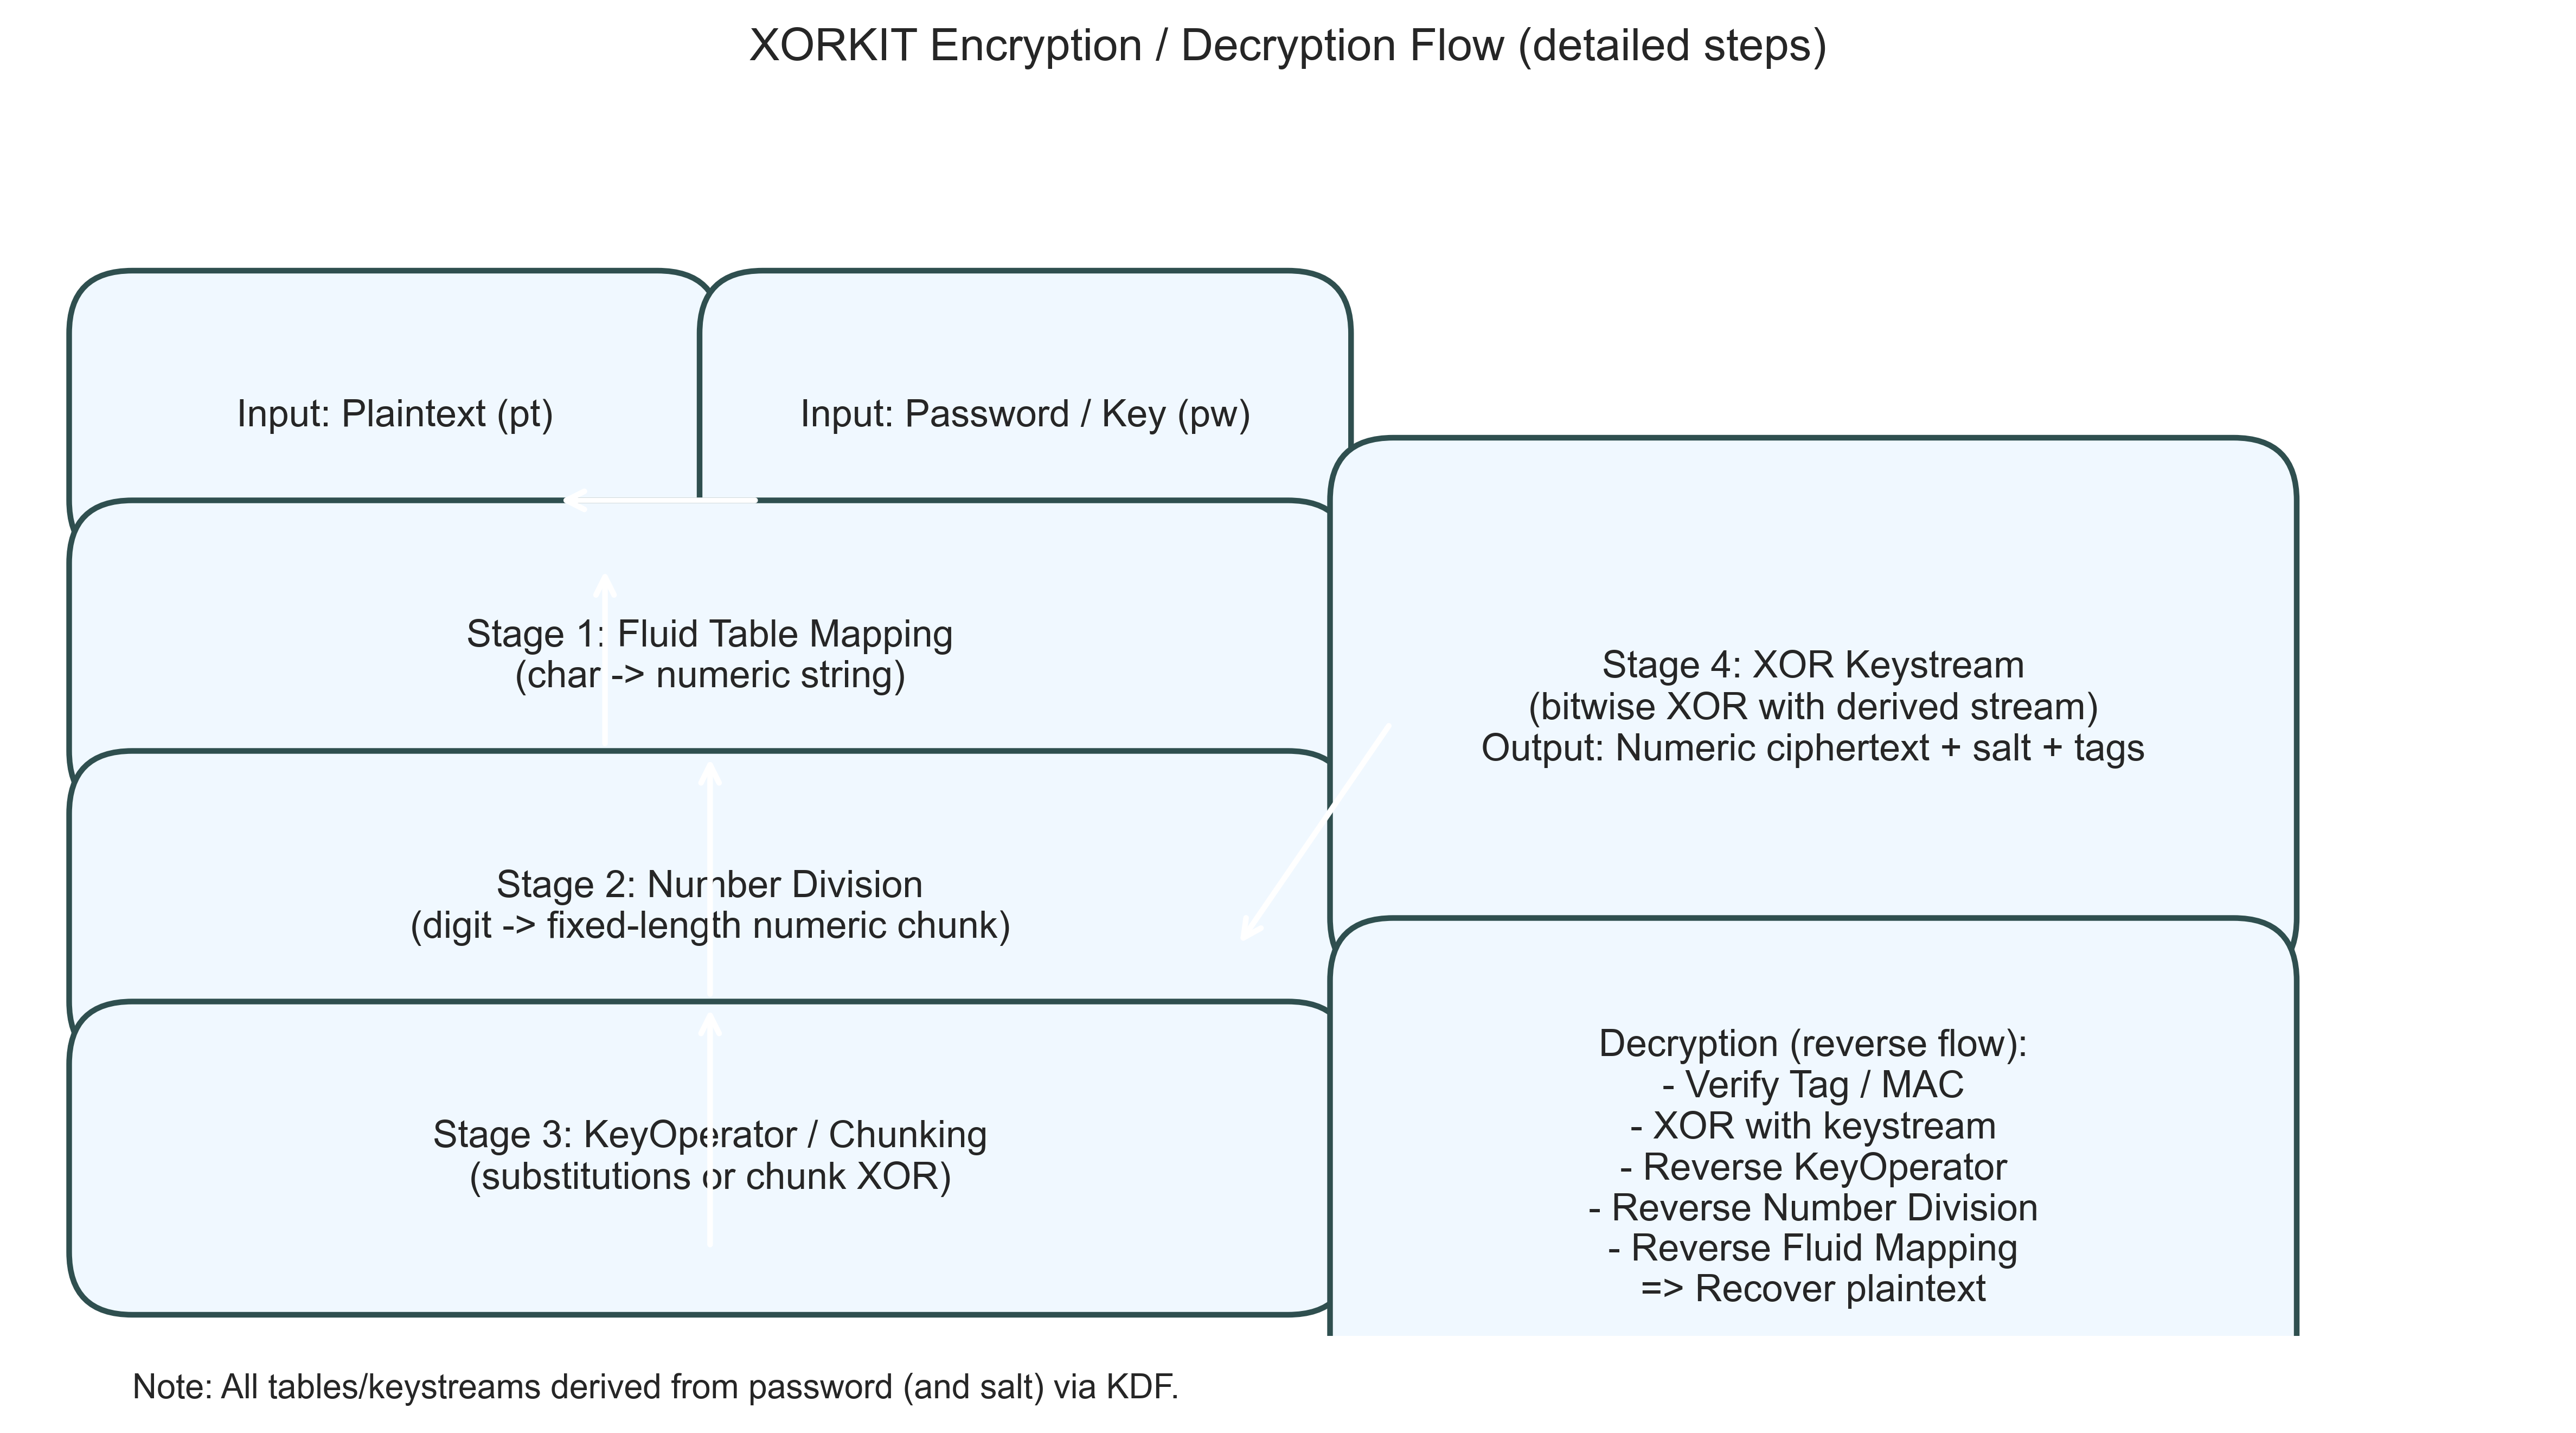

Saved encryption/decryption flow diagram.


In [19]:
# Cell 14: Draw flowchart of encryption/decryption process using matplotlib
def draw_flowchart(savepath):
    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_xlim(0, 12); ax.set_ylim(0, 6)
    ax.axis('off')

    def box(x,y,w,h,text):
        rect = patches.FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.3", edgecolor="#2f4f4f", facecolor="#f0f8ff", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=10, wrap=True)

    # Encryption boxes
    box(0.5, 4.0, 2.5, 0.8, "Input: Plaintext (pt)")
    box(3.5, 4.0, 2.5, 0.8, "Input: Password / Key (pw)")
    box(0.5, 2.8, 5.5, 0.9, "Stage 1: Fluid Table Mapping\n(char -> numeric string)")
    box(0.5, 1.6, 5.5, 0.9, "Stage 2: Number Division\n(digit -> fixed-length numeric chunk)")
    box(0.5, 0.4, 5.5, 0.9, "Stage 3: KeyOperator / Chunking\n(substitutions or chunk XOR)")
    box(6.5, 2.0, 4.0, 2.0, "Stage 4: XOR Keystream\n(bitwise XOR with derived stream)\nOutput: Numeric ciphertext + salt + tags")

    # arrows
    ax.annotate("", xy=(2.5,4.0), xytext=(3.5,4.0), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(2.75,3.7), xytext=(2.75,2.8), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(3.25,2.8), xytext=(3.25,1.6), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(3.25,1.6), xytext=(3.25,0.4), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(5.75,1.85), xytext=(6.5,2.95), arrowprops=dict(arrowstyle="->", lw=1.5))

    # decryption side
    box(6.5, -0.1, 4.0, 1.8, "Decryption (reverse flow):\n- Verify Tag / MAC\n- XOR with keystream\n- Reverse KeyOperator\n- Reverse Number Division\n- Reverse Fluid Mapping\n=> Recover plaintext")

    ax.text(0.5, -0.3, "Note: All tables/keystreams derived from password (and salt) via KDF.", fontsize=9)

    plt.title("XORKIT Encryption / Decryption Flow (detailed steps)", fontsize=12)
    plt.savefig(savepath, dpi=EXPORT_PNG_DPI, bbox_inches='tight')
    plt.show()

draw_flowchart(os.path.join(SAVE_DIR, "xorkit_flow_diagram.png"))
print("Saved encryption/decryption flow diagram.")


In [20]:
# Cell 15: Produce human-readable report per metric (text files + CSV)
def write_report(title, description, dataframe, csv_name, png=None):
    txt = f"=== {title} ===\n\n{description}\n\nSummary statistics:\n{dataframe.describe()}\n"
    with open(os.path.join(SAVE_DIR, csv_name.replace('.csv','.txt')), "w") as f:
        f.write(txt)
    dataframe.describe().to_csv(os.path.join(SAVE_DIR, csv_name))

# Example reports
write_report(
    "Performance (Encryption/Decryption)",
    "Encryption and decryption time measured using time.perf_counter(). Values in seconds. Use median & 95% percentiles for robust reporting.",
    df[['enc_time_s','dec_time_s']], "performance_report.csv"
)

write_report(
    "Entropy & Randomness",
    "Shannon entropy per ciphertext byte, chi-square p-values, serial correlation and runs test p-values.",
    df[['cipher_entropy','chi2','chi_p','serial_corr','runs_p']], "entropy_randomness_report.csv"
)

write_report(
    "Avalanche & Key Sensitivity (sampled)",
    "Sampled avalanche and key sensitivity statistics saved separately.",
    pd.DataFrame({"avalanche_sampled":avals, "key_sensitivity_sampled":kvals}) if 'avals' in globals() else pd.DataFrame(),
    "avalanche_keysens_report.csv"
)

print("Saved textual reports + CSVs in", SAVE_DIR)


Saved textual reports + CSVs in xorkit_results_20000


In [21]:
# Cell 16: Final summary (print concise statements you can paste into the paper)
summary = {
    "N": len(df),
    "decryption_accuracy_pct": df['correct'].mean()*100,
    "enc_time_mean_ms": df['enc_time_s'].mean()*1000,
    "dec_time_mean_ms": df['dec_time_s'].mean()*1000,
    "cipher_entropy_mean": df['cipher_entropy'].mean(),
    "avalanche_mean_pct": mean(avals) if 'avals' in globals() and len(avals)>0 else None,
    "key_sensitivity_mean_pct": mean(kvals) if 'kvals' in globals() and len(kvals)>0 else None,
}
print("=== Summary (copy for manuscript) ===")
print(json.dumps(summary, indent=2))
with open(os.path.join(SAVE_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Saved summary.json")


=== Summary (copy for manuscript) ===
{
  "N": 20000,
  "decryption_accuracy_pct": 0.0,
  "enc_time_mean_ms": 165.11235716499942,
  "dec_time_mean_ms": 224.89450236997362,
  "cipher_entropy_mean": 6.536897612498443,
  "avalanche_mean_pct": 50.009056784993795,
  "key_sensitivity_mean_pct": 49.9612669526772
}
Saved summary.json


In [24]:
# 🧩 Clean and Well-Spaced XORKIT Encryption–Decryption Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

EXPORT_PNG_DPI = 500
SAVE_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)

def draw_xorkit_flow_clean(savepath):
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 14)
    ax.axis('off')

    # Helper functions
    def box(x, y, w, h, text, color="#f8fbff", edge="#003366"):
        rect = patches.FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0.4",
            edgecolor=edge, facecolor=color, linewidth=1.6
        )
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text,
                ha='center', va='center', fontsize=9.5, wrap=True, color="#001f3f")

    def arrow(x1, y1, x2, y2, color="#003366", text=None):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.4, color=color))
        if text:
            ax.text((x1+x2)/2, (y1+y2)/2+0.1, text, ha='center', fontsize=8, color=color)

    # Layout constants
    left_x, right_x = 1.5, 10.5
    width, height, gap = 6.0, 0.9, 0.8

    # ---------------- ENCRYPTION STAGES ----------------
    y = 13
    box(left_x, y, width, height, "🔹 **Input Stage**\nPlaintext: `helloWorld123!`\nPassword: `TestPass123`")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 1️⃣: **Key Derivation (KDF)**\n→ PBKDF2-HMAC-SHA256(pw, salt)\n→ Derives SK1–SK4 (e.g., SK1=`b3a4f1...`)")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 2️⃣: **Fluid Table Mapping**\n→ Map chars→numeric codes (SK1)\nExample: `h→482193017384`, `e→012875194632`")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 3️⃣: **Number Division**\n→ Split numeric string→3-digit chunks\nExample: `482193...`→`048|219|301|738|...`")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 4️⃣: **Key Operator Layer**\n→ Substitution via SK3, adds key entropy\nExample: `048→193`, `219→054`")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 5️⃣: **XOR Keystream**\n→ Generate keystream from SK4\n→ XOR numeric data to produce cipher")
    y -= (height + gap)
    box(left_x, y, width, height, "Stage 6️⃣: **Tag & Output Generation**\n→ Create HMAC tag\n→ Output: {cipher, salt, tag}")
    y -= (height + gap)
    box(left_x, y, width, height, "🔸 **Output:** Encrypted Envelope\n(ciphertext + salt + tag)")

    # Arrows (encryption)
    for i in range(13, 7, -1):
        arrow(left_x + width/2, i, left_x + width/2, i - (height + gap) + 0.2)

    # ---------------- DECRYPTION STAGES ----------------
    y = 5
    box(right_x, y, width, height, "🔹 **Input:** Encrypted Envelope\n(cipher, salt, tag)")
    y += (height + gap)
    box(right_x, y, width, height, "Stage 1️⃣: **Verify Tag / Integrity**\n→ Recompute HMAC, abort if mismatch")
    y += (height + gap)
    box(right_x, y, width, height, "Stage 2️⃣: **Reverse XOR Keystream**\n→ Regenerate SK4 stream\n→ XOR back to recover numeric")
    y += (height + gap)
    box(right_x, y, width, height, "Stage 3️⃣: **Reverse Key Operator**\n→ Undo substitution using SK3")
    y += (height + gap)
    box(right_x, y, width, height, "Stage 4️⃣: **Reverse Number Division**\n→ Merge chunks → full numeric string")
    y += (height + gap)
    box(right_x, y, width, height, "Stage 5️⃣: **Reverse Fluid Mapping**\n→ Convert numeric→chars using SK1\n`482193017384→h`, `012875194632→e`")
    y += (height + gap)
    box(right_x, y, width, height, "🔸 **Output:** Recovered Plaintext\n✅ `helloWorld123!`")

    # Arrows (decryption)
    for i in range(5, 10):
        arrow(right_x + width/2, i + 0.6, right_x + width/2, i + 1.4)

    # Horizontal connector
    arrow(left_x + width + 0.3, 6.2, right_x - 0.3, 6.2, text="Encrypted Envelope → Decryption")

    # Titles
    ax.text(left_x + width/2, 13.9, "🔒 ENCRYPTION FLOW", fontsize=13, fontweight='bold', color="#003366", ha='center')
    ax.text(right_x + width/2, 11.8, "🔓 DECRYPTION FLOW", fontsize=13, fontweight='bold', color="#660000", ha='center')
    ax.text(9, 4.5, "🔁 Symmetric Process – Same Password Enables Decryption", fontsize=10, ha='center', color="#333333")

    plt.title("🔐 XORKIT Encryption–Decryption Flow (Clean & Readable Layout)", fontsize=15, fontweight='bold', color="#001f3f")
    plt.tight_layout()
    plt.savefig(savepath, dpi=EXPORT_PNG_DPI, bbox_inches='tight')
    plt.show()

draw_xorkit_flow_clean(os.path.join(SAVE_DIR, "xorkit_clean_flow_v2.png"))
print("✅ Clean, balanced encryption-decryption flow diagram saved.")




C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shakti singh\AppData\Local\Temp\ipykernel_20792\575358034.py:87: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHEC

✅ Clean, balanced encryption-decryption flow diagram saved.
